In [1]:
"""
Nassau Candy Distributor — Stage 1: Data Preparation & Encoding
================================================================
This script:
  1. Loads the raw dataset
  2. Adds factory assignment per product (from provided factory-product mapping)
  3. Engineers factory & destination coordinates, and shipping distance (haversine)
  4. Engineers the target variable (Lead Time)
  5. Removes outliers using the IQR method on financial columns
  6. Encodes categorical variables (Label Encoding)
  7. Normalizes numerical features (StandardScaler)
  8. Saves the final enriched feature matrix ready for modeling (Stage 2)

Factory coordinates provided by Nassau Candy:
  - Lot's O' Nuts      : (32.881893, -111.768036)
  - Wicked Choccy's   : (32.076176,  -81.088371)
  - Sugar Shack        : (48.119140,  -96.181150)
  - Secret Factory     : (41.446333,  -90.565487)
  - The Other Factory  : (35.117500,  -89.971107)
"""

import pandas as pd
import numpy as np
import math
import pickle
import os
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── 0. Config ──────────────────────────────────────────────────────────────────
INPUT_PATH = "Dataset/Nassau Candy Distributor.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Reference data — factories & product mapping ───────────────────────────
FACTORIES = {
    "Lot's O' Nuts":     (32.881893, -111.768036),
    "Wicked Choccy's":  (32.076176,  -81.088371),
    "Sugar Shack":       (48.11914,   -96.18115),
    "Secret Factory":    (41.446333,  -90.565487),
    "The Other Factory": (35.1175,    -89.971107),
}

PRODUCT_FACTORY = {
    "Wonka Bar - Nutty Crunch Surprise":   "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows":           "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious":      "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate":          "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel":   "Wicked Choccy's",
    "Laffy Taffy":                         "Sugar Shack",
    "SweeTARTS":                           "Sugar Shack",
    "Nerds":                               "Sugar Shack",
    "Fun Dip":                             "Sugar Shack",
    "Fizzy Lifting Drinks":                "Sugar Shack",
    "Everlasting Gobstopper":              "Secret Factory",
    "Hair Toffee":                         "The Other Factory",
    "Lickable Wallpaper":                  "Secret Factory",
    "Wonka Gum":                           "Secret Factory",
    "Kazookles":                           "The Other Factory",
}

# US state & Canadian province centroids (approximate lat/lon)
STATE_COORDS = {
    'Alabama': (32.7,-86.7),'Alaska': (64.2,-153.4),'Arizona': (34.3,-111.1),
    'Arkansas': (34.8,-92.2),'California': (36.8,-119.4),'Colorado': (39.0,-105.5),
    'Connecticut': (41.6,-72.7),'Delaware': (39.0,-75.5),'Florida': (27.8,-81.5),
    'Georgia': (32.7,-83.4),'Hawaii': (20.9,-156.4),'Idaho': (44.1,-114.5),
    'Illinois': (40.0,-89.2),'Indiana': (39.9,-86.3),'Iowa': (42.0,-93.5),
    'Kansas': (38.5,-98.4),'Kentucky': (37.5,-85.3),'Louisiana': (31.2,-91.8),
    'Maine': (45.4,-69.0),'Maryland': (39.1,-76.8),'Massachusetts': (42.3,-71.8),
    'Michigan': (44.3,-85.4),'Minnesota': (46.4,-93.1),'Mississippi': (32.7,-89.7),
    'Missouri': (38.5,-92.5),'Montana': (47.0,-110.5),'Nebraska': (41.5,-99.9),
    'Nevada': (39.5,-116.9),'New Hampshire': (43.7,-71.6),'New Jersey': (40.1,-74.5),
    'New Mexico': (34.8,-106.2),'New York': (42.9,-75.6),'North Carolina': (35.5,-79.4),
    'North Dakota': (47.5,-100.5),'Ohio': (40.4,-82.8),'Oklahoma': (35.6,-97.5),
    'Oregon': (44.1,-120.5),'Pennsylvania': (40.6,-77.2),'Rhode Island': (41.7,-71.5),
    'South Carolina': (33.8,-81.2),'South Dakota': (44.4,-100.2),'Tennessee': (35.9,-86.7),
    'Texas': (31.1,-97.6),'Utah': (39.3,-111.1),'Vermont': (44.1,-72.7),
    'Virginia': (37.5,-79.5),'Washington': (47.4,-120.5),'West Virginia': (38.6,-80.6),
    'Wisconsin': (44.3,-89.8),'Wyoming': (43.0,-107.6),
    'District of Columbia': (38.9,-77.0),
    # Canadian provinces
    'Ontario': (51.3,-85.3),'Quebec': (52.9,-73.5),'British Columbia': (53.7,-127.6),
    'Alberta': (55.0,-115.0),'Manitoba': (55.0,-97.0),'Saskatchewan': (55.0,-106.0),
    'Nova Scotia': (45.0,-63.0),'New Brunswick': (46.6,-66.5),
    'Newfoundland and Labrador': (53.1,-57.6),'Prince Edward Island': (46.5,-63.3),
}

# ── 2. Haversine distance (no external library needed) ────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles between two lat/lon coordinates."""
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# ── 3. Load raw data ───────────────────────────────────────────────────────────
print("=" * 65)
print("STAGE 1: DATA PREPARATION & ENCODING")
print("=" * 65)

df = pd.read_csv(INPUT_PATH)
print(f"\n✔ Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── 4. Engineer target variable: Lead Time (days) ─────────────────────────────
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)
df["Lead_Time"]  = (df["Ship Date"] - df["Order Date"]).dt.days

print(f"\n── Target Variable: Lead_Time ──")
print(f"   Mean   : {df['Lead_Time'].mean():.1f} days")
print(f"   Std Dev: {df['Lead_Time'].std():.1f} days")
print(f"   Min    : {df['Lead_Time'].min()} days")
print(f"   Max    : {df['Lead_Time'].max()} days")

# ── 5. Add factory features ────────────────────────────────────────────────────
print(f"\n── Adding Factory Features ──")

df["Factory"]     = df["Product Name"].map(PRODUCT_FACTORY)
df["Factory_Lat"] = df["Factory"].map(lambda f: FACTORIES[f][0] if f in FACTORIES else np.nan)
df["Factory_Lon"] = df["Factory"].map(lambda f: FACTORIES[f][1] if f in FACTORIES else np.nan)

df["Dest_Lat"] = df["State/Province"].map(lambda s: STATE_COORDS.get(s, (np.nan, np.nan))[0])
df["Dest_Lon"] = df["State/Province"].map(lambda s: STATE_COORDS.get(s, (np.nan, np.nan))[1])

df["Shipping_Distance_Miles"] = df.apply(
    lambda r: haversine(r["Factory_Lat"], r["Factory_Lon"], r["Dest_Lat"], r["Dest_Lon"])
              if not any(np.isnan([r["Factory_Lat"], r["Dest_Lat"]])) else np.nan,
    axis=1
)

# Drop rows where distance couldn't be computed (unmapped states)
unmapped = df[df["Shipping_Distance_Miles"].isna()]["State/Province"].unique()
if len(unmapped):
    print(f"   Unmapped states (dropped): {list(unmapped)}")
df = df.dropna(subset=["Shipping_Distance_Miles"]).reset_index(drop=True)

print(f"   ✔ Factory assigned across {df['Factory'].nunique()} factories")
print(f"   ✔ Shipping distance — mean: {df['Shipping_Distance_Miles'].mean():.0f} mi, "
      f"range: {df['Shipping_Distance_Miles'].min():.0f}–{df['Shipping_Distance_Miles'].max():.0f} mi")
print(f"   Rows after coordinate mapping: {len(df):,}")

# ── 6. Select columns for modeling ────────────────────────────────────────────
CATEGORICAL_COLS = ["Ship Mode", "Region", "Division", "Factory", "Product ID", "Country/Region"]
NUMERICAL_COLS   = ["Sales", "Units", "Gross Profit", "Cost",
                    "Factory_Lat", "Factory_Lon", "Dest_Lat", "Dest_Lon",
                    "Shipping_Distance_Miles"]
TARGET_COL       = "Lead_Time"

df_model = df[CATEGORICAL_COLS + NUMERICAL_COLS + [TARGET_COL]].copy()
print(f"\n── Selected {len(CATEGORICAL_COLS)} categorical + "
      f"{len(NUMERICAL_COLS)} numerical features + 1 target ──")

# ── 7. Remove outliers (IQR on financial columns only) ────────────────────────
# Coordinate and distance columns are NOT outlier-filtered —
# they are deterministic geographic values, not measurements.
OUTLIER_COLS = ["Sales", "Units", "Gross Profit", "Cost"]

print(f"\n── Outlier Removal (IQR method — financial columns only) ──")
rows_before = len(df_model)

for col in OUTLIER_COLS:
    q1    = df_model[col].quantile(0.25)
    q3    = df_model[col].quantile(0.75)
    iqr   = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    out_count = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    df_model  = df_model[(df_model[col] >= lower) & (df_model[col] <= upper)]
    print(f"   {col:<25}: removed {out_count:>3} outliers  (bounds: {lower:.2f} – {upper:.2f})")

rows_after = len(df_model)
print(f"\n   Rows before: {rows_before:,}  →  Rows after: {rows_after:,}  "
      f"(removed {rows_before - rows_after:,})")

# ── 8. Encode categorical variables ───────────────────────────────────────────
print(f"\n── Encoding Categorical Variables ──")

label_encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    mapping = {cls: int(code) for cls, code in
               zip(le.classes_, le.transform(le.classes_))}
    print(f"   {col:<20}: {len(le.classes_)} categories → {mapping}")

# ── 9. Normalize numerical features ───────────────────────────────────────────
print(f"\n── Normalizing Numerical Features (StandardScaler) ──")

scaler     = StandardScaler()
num_scaled = scaler.fit_transform(df_model[NUMERICAL_COLS])
df_scaled  = pd.DataFrame(num_scaled,
                           columns=[c + "_scaled" for c in NUMERICAL_COLS],
                           index=df_model.index)

print(f"   Scaled {len(NUMERICAL_COLS)} numerical columns")
print(f"   Mean ≈ 0 check: {df_scaled.mean().round(3).to_dict()}")
print(f"   Std  ≈ 1 check: {df_scaled.std().round(3).to_dict()}")

# ── 10. Build final feature matrix ─────────────────────────────────────────────
enc_cols = [c + "_enc"    for c in CATEGORICAL_COLS]
sca_cols = [c + "_scaled" for c in NUMERICAL_COLS]

X = pd.concat([df_model[enc_cols].reset_index(drop=True),
               df_scaled.reset_index(drop=True)], axis=1)
y = df_model[TARGET_COL].reset_index(drop=True)

print(f"\n── Final Feature Matrix ──")
print(f"   X shape : {X.shape}  (samples × features)")
print(f"   y shape : {y.shape}  (target: Lead_Time in days)")
print(f"\n   Feature columns:")
for col in X.columns:
    print(f"      • {col}")

# ── 11. Save outputs ────────────────────────────────────────────────────────────
# Feature matrix & target
X.to_csv(f"{OUTPUT_DIR}/X_features.csv", index=False)
y.to_csv(f"{OUTPUT_DIR}/y_target.csv",   index=False)

# Full enriched dataset — master file used by all downstream stages
df_full = pd.concat([
    df_model[CATEGORICAL_COLS + NUMERICAL_COLS].reset_index(drop=True),
    X,
    y
], axis=1)
df_full.to_csv(f"{OUTPUT_DIR}/nassau_enriched.csv", index=False)

# Fitted preprocessing objects for reuse in Stages 2–6
with open(f"{OUTPUT_DIR}/scaler.pkl", "wb") as f:
    pickle.dump({"scaler": scaler, "numerical_cols": NUMERICAL_COLS}, f)
with open(f"{OUTPUT_DIR}/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print(f"\n── Saved Outputs to {OUTPUT_DIR}/ ──")
print(f"   ✔ X_features.csv      — feature matrix (encoded + scaled)")
print(f"   ✔ y_target.csv        — target variable (Lead_Time)")
print(f"   ✔ nassau_enriched.csv — full enriched dataset (master file for all stages)")
print(f"   ✔ scaler.pkl          — fitted StandardScaler")
print(f"   ✔ label_encoders.pkl  — fitted LabelEncoders")
print(f"\n{'=' * 65}")
print("Stage 1 complete. Ready for Stage 2: Predictive Modeling.")
print("=" * 65)

STAGE 1: DATA PREPARATION & ENCODING

✔ Loaded dataset: 10,194 rows × 18 columns

── Target Variable: Lead_Time ──
   Mean   : 1320.8 days
   Std Dev: 262.4 days
   Min    : 904 days
   Max    : 1642 days

── Adding Factory Features ──
   ✔ Factory assigned across 5 factories
   ✔ Shipping distance — mean: 1235 mi, range: 105–2983 mi
   Rows after coordinate mapping: 10,194

── Selected 6 categorical + 9 numerical features + 1 target ──

── Outlier Removal (IQR method — financial columns only) ──
   Sales                    : removed 245 outliers  (bounds: -9.00 – 34.20)
   Units                    : removed  18 outliers  (bounds: -2.50 – 9.50)
   Gross Profit             : removed   1 outliers  (bounds: -5.75 – 22.65)
   Cost                     : removed 147 outliers  (bounds: -2.55 – 10.65)

   Rows before: 10,194  →  Rows after: 9,783  (removed 411)

── Encoding Categorical Variables ──
   Ship Mode           : 4 categories → {'First Class': 0, 'Same Day': 1, 'Second Class': 2, 'St

✔ Dashboard saved to outputs


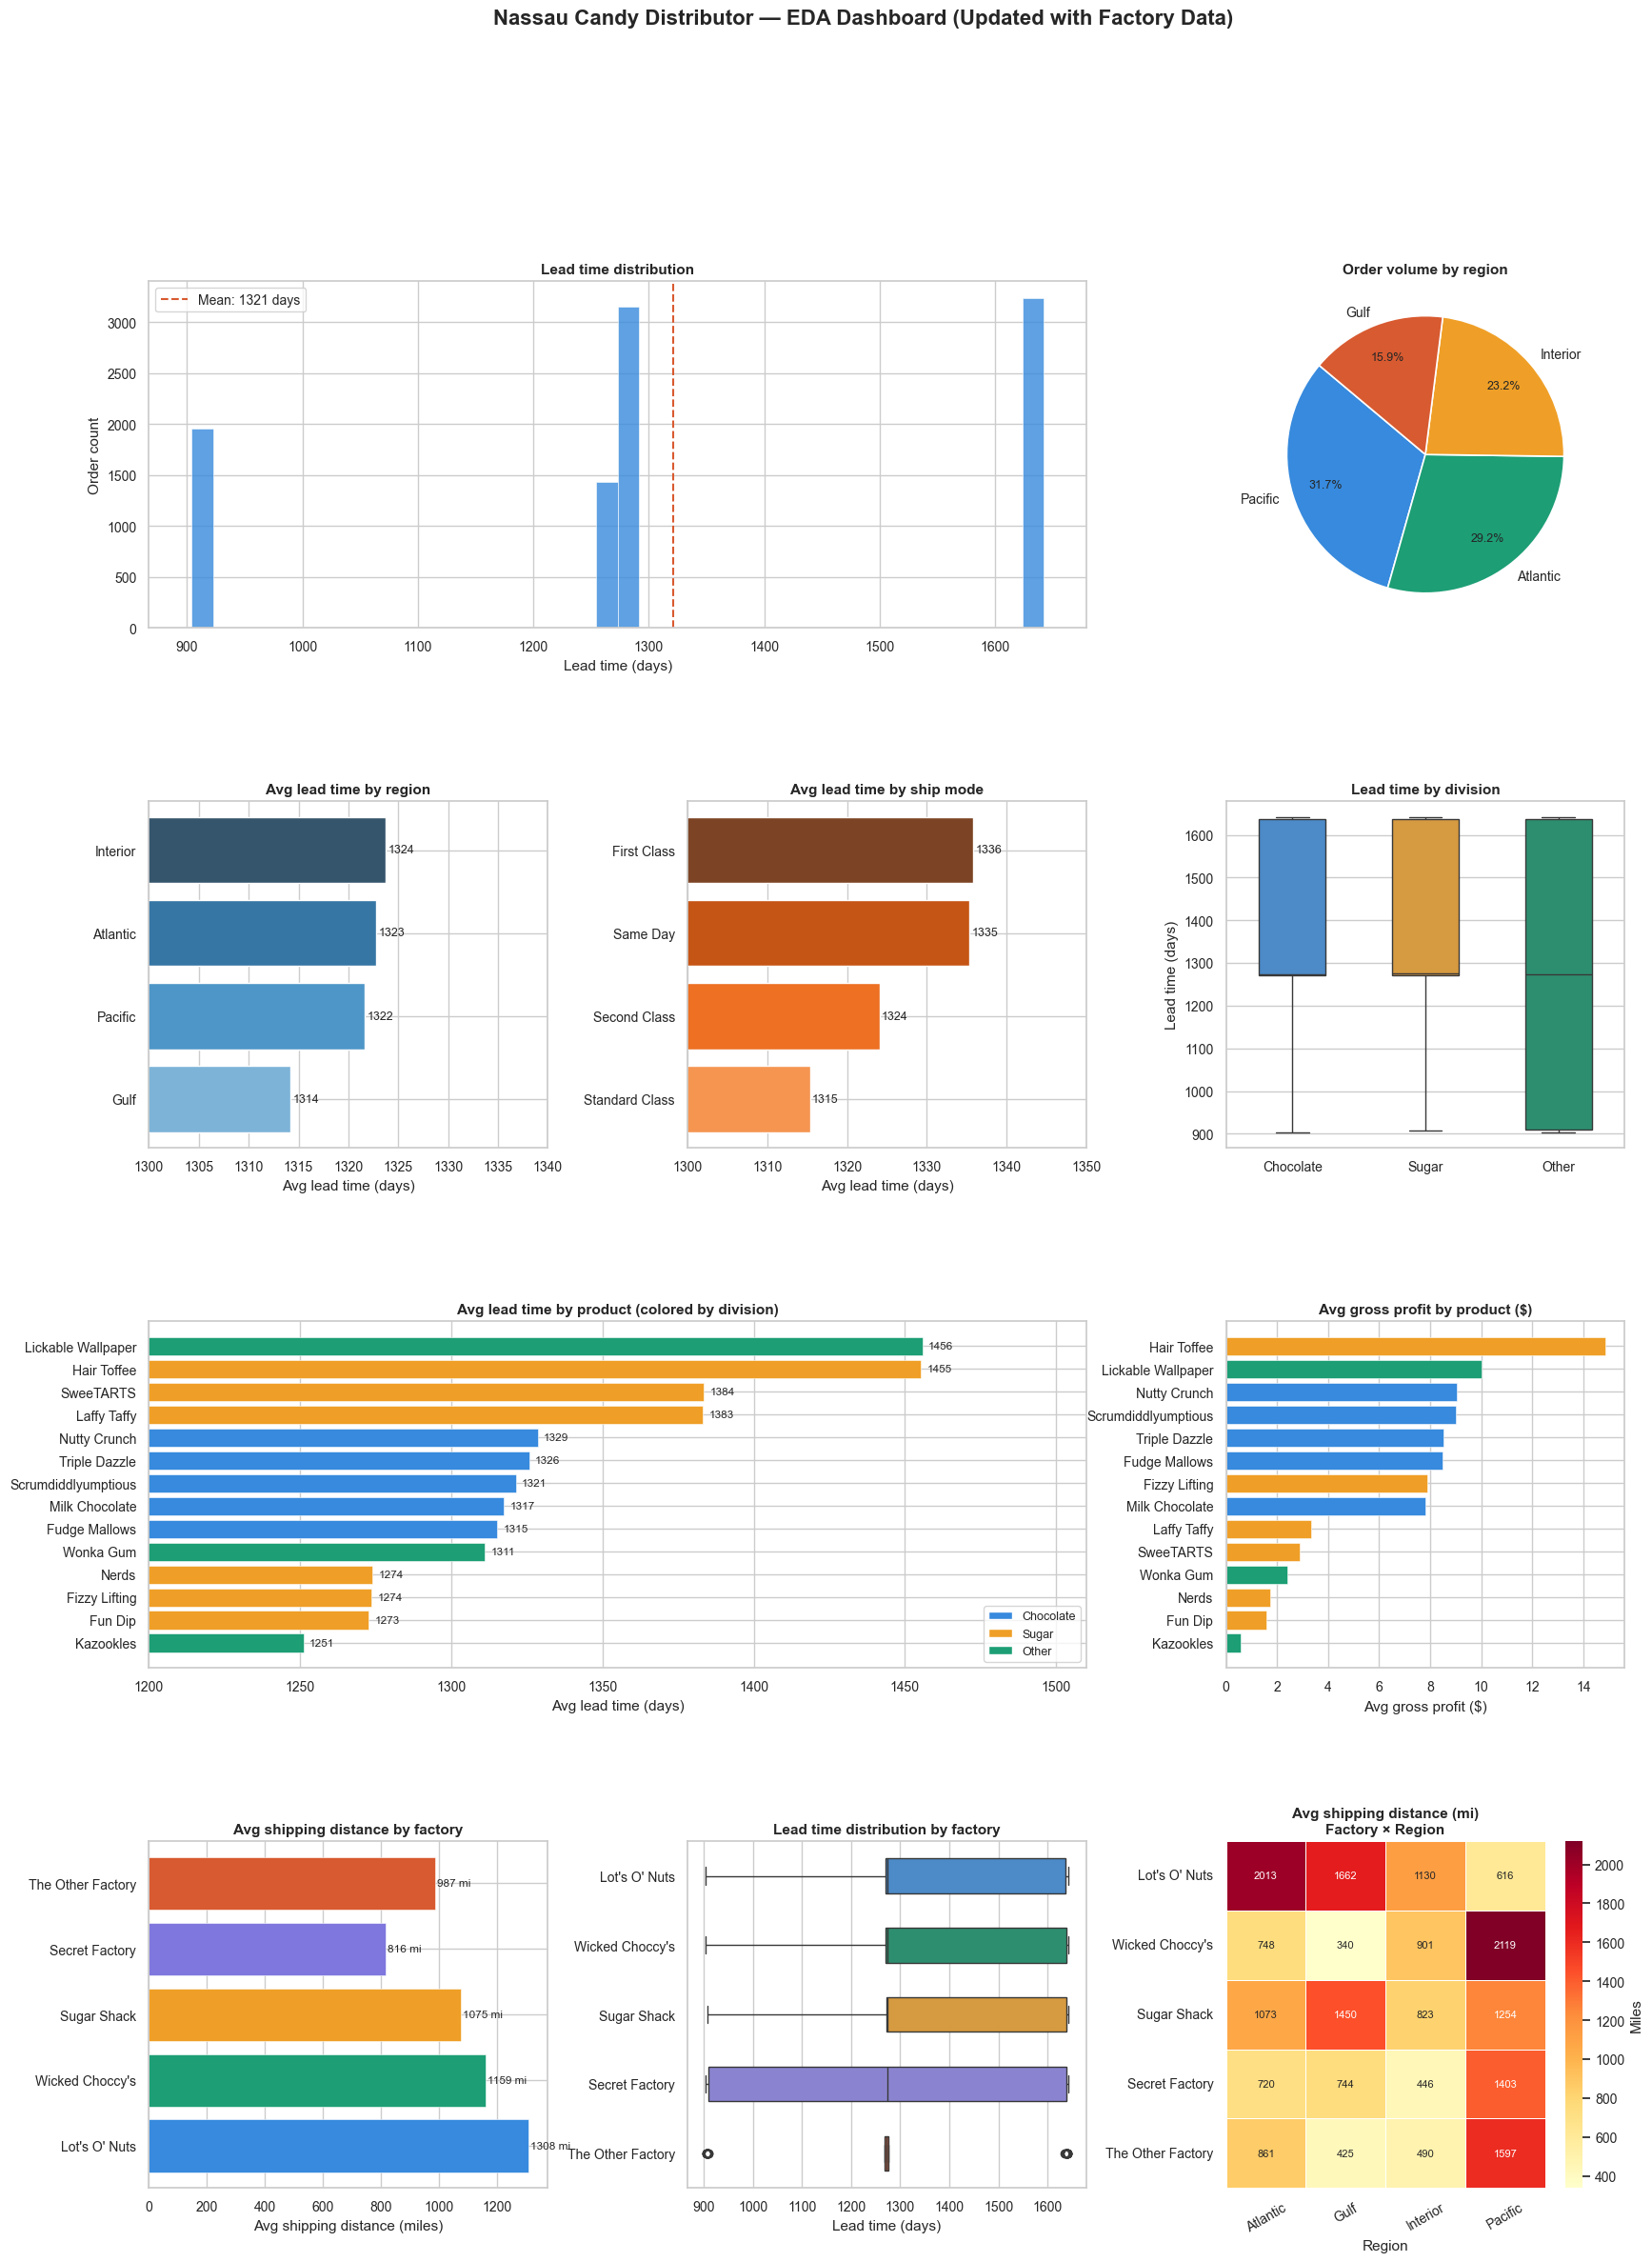

In [2]:
"""
Nassau Candy Distributor — EDA Visualization (Updated)
=======================================================
Updated to use nassau_enriched.csv which now includes:
  - Factory assignment per product
  - Factory & destination coordinates
  - Shipping distance (miles)

Charts:
  1.  Lead time distribution (histogram)
  2.  Order volume by region (pie)
  3.  Avg lead time by region (bar)
  4.  Avg lead time by ship mode (bar)
  5.  Lead time distribution by division (boxplot)
  6.  Avg lead time by product — colored by division (bar)
  7.  Avg gross profit by product (bar)
  8.  Avg shipping distance by factory (bar)        *NEW*
  9.  Lead time by factory (boxplot)                *NEW*
  10. Shipping distance by factory × region (heatmap) *NEW*

Input  : nassau_enriched.csv  (from updated Stage 1)
Output : nassau_eda_dashboard.png
"""

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# ── 0. Config ───────────────────────────────────────────────────────────────
INPUT_PATH = "outputs/nassau_enriched.csv"
# ── 1. Load data ───────────────────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)

prod_names = {
    'CHO-FUD-51000': 'Fudge Mallows',       'CHO-MIL-31000': 'Milk Chocolate',
    'CHO-NUT-13000': 'Nutty Crunch',        'CHO-SCR-58000': 'Scrumdiddlyumptious',
    'CHO-TRI-54000': 'Triple Dazzle',       'OTH-FIZ-56000': 'Fizzy Lifting',
    'OTH-GUM-21000': 'Wonka Gum',           'OTH-KAZ-38000': 'Kazookles',
    'OTH-LIC-15000': 'Lickable Wallpaper',  'SUG-FUN-75000': 'Fun Dip',
    'SUG-HAI-55000': 'Hair Toffee',         'SUG-LAF-25000': 'Laffy Taffy',
    'SUG-NER-92000': 'Nerds',               'SUG-SWE-91000': 'SweeTARTS',
}
df['Product Name'] = df['Product ID'].map(prod_names)

# Consistent color palettes
div_palette     = {'Chocolate': '#378ADD', 'Sugar': '#EF9F27', 'Other': '#1D9E75'}
factory_palette = {
    "Lot's O' Nuts":     '#378ADD',
    "Wicked Choccy's":  '#1D9E75',
    "Sugar Shack":       '#EF9F27',
    "Secret Factory":    '#7F77DD',
    "The Other Factory": '#D85A30',
}
factory_order = ["Lot's O' Nuts", "Wicked Choccy's", "Sugar Shack",
                 "Secret Factory", "The Other Factory"]

# ── 2. Global style ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=0.92)

# ── 3. Figure layout (4 rows × 3 cols) ────────────────────────────────────────
fig = plt.figure(figsize=(20, 26))
fig.suptitle('Nassau Candy Distributor — EDA Dashboard (Updated with Factory Data)',
             fontsize=16, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.50, wspace=0.35)

# ── Plot 1: Lead time distribution (histogram) ─────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
sns.histplot(df['Lead_Time'], bins=40, color='#378ADD', alpha=0.8,
             ax=ax1, edgecolor='white', linewidth=0.4)
ax1.axvline(df['Lead_Time'].mean(), color='#D85A30', linestyle='--',
            linewidth=1.5, label=f"Mean: {df['Lead_Time'].mean():.0f} days")
ax1.set_title('Lead time distribution', fontweight='bold')
ax1.set_xlabel('Lead time (days)')
ax1.set_ylabel('Order count')
ax1.legend()

# ── Plot 2: Order volume by region (pie) ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
region_counts = df['Region'].value_counts()
wedges, texts, autotexts = ax2.pie(
    region_counts, labels=region_counts.index, autopct='%1.1f%%',
    colors=['#378ADD', '#1D9E75', '#EF9F27', '#D85A30'],
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Order volume by region', fontweight='bold')

# ── Plot 3: Avg lead time by region (bar) ──────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
region_lt = df.groupby('Region')['Lead_Time'].mean().sort_values().reset_index()
ax3.barh(region_lt['Region'], region_lt['Lead_Time'],
         color=sns.color_palette('Blues_d', len(region_lt)), edgecolor='white')
ax3.set_xlim(1300, 1340)
for i, v in enumerate(region_lt['Lead_Time']):
    ax3.text(v + 0.3, i, f'{v:.0f}', va='center', fontsize=9)
ax3.set_title('Avg lead time by region', fontweight='bold')
ax3.set_xlabel('Avg lead time (days)')

# ── Plot 4: Avg lead time by ship mode (bar) ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
mode_lt = df.groupby('Ship Mode')['Lead_Time'].mean().sort_values().reset_index()
ax4.barh(mode_lt['Ship Mode'], mode_lt['Lead_Time'],
         color=sns.color_palette('Oranges_d', len(mode_lt)), edgecolor='white')
ax4.set_xlim(1300, 1350)
for i, v in enumerate(mode_lt['Lead_Time']):
    ax4.text(v + 0.3, i, f'{v:.0f}', va='center', fontsize=9)
ax4.set_title('Avg lead time by ship mode', fontweight='bold')
ax4.set_xlabel('Avg lead time (days)')

# ── Plot 5: Lead time by division (boxplot) ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
sns.boxplot(data=df, x='Division', y='Lead_Time',
            hue='Division', palette=div_palette, legend=False,
            ax=ax5, order=['Chocolate', 'Sugar', 'Other'],
            width=0.5, linewidth=1)
ax5.set_title('Lead time by division', fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('Lead time (days)')

# ── Plot 6: Avg lead time by product (bar, colored by division) ────────────────
ax6 = fig.add_subplot(gs[2, :2])
prod_lt = (df.groupby(['Product Name', 'Division'])['Lead_Time']
             .mean().reset_index().sort_values('Lead_Time'))
bar_colors6 = [div_palette[d] for d in prod_lt['Division']]
bars6 = ax6.barh(prod_lt['Product Name'], prod_lt['Lead_Time'],
                 color=bar_colors6, edgecolor='white', linewidth=0.4)
ax6.set_xlim(1200, 1510)
for bar, val in zip(bars6, prod_lt['Lead_Time']):
    ax6.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}', va='center', fontsize=8.5)
ax6.set_title('Avg lead time by product (colored by division)', fontweight='bold')
ax6.set_xlabel('Avg lead time (days)')
legend_div = [mpatches.Patch(facecolor=c, label=d) for d, c in div_palette.items()]
ax6.legend(handles=legend_div, loc='lower right', fontsize=9)

# ── Plot 7: Avg gross profit by product (bar) ──────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
prod_gp = (df.groupby(['Product Name', 'Division'])['Gross Profit']
             .mean().reset_index().sort_values('Gross Profit'))
ax7.barh(prod_gp['Product Name'], prod_gp['Gross Profit'],
         color=[div_palette[d] for d in prod_gp['Division']],
         edgecolor='white', linewidth=0.4)
ax7.set_title('Avg gross profit by product ($)', fontweight='bold')
ax7.set_xlabel('Avg gross profit ($)')

# ── Plot 8: Avg shipping distance by factory (bar) — NEW ──────────────────────
ax8 = fig.add_subplot(gs[3, 0])
fac_dist = (df.groupby('Factory')['Shipping_Distance_Miles']
              .mean().reindex(factory_order).reset_index())
fac_colors8 = [factory_palette[f] for f in fac_dist['Factory']]
bars8 = ax8.barh(fac_dist['Factory'], fac_dist['Shipping_Distance_Miles'],
                 color=fac_colors8, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars8, fac_dist['Shipping_Distance_Miles']):
    ax8.text(val + 5, bar.get_y() + bar.get_height()/2,
             f'{val:.0f} mi', va='center', fontsize=8.5)
ax8.set_title('Avg shipping distance by factory', fontweight='bold')
ax8.set_xlabel('Avg shipping distance (miles)')

# ── Plot 9: Lead time by factory (boxplot) — NEW ──────────────────────────────
ax9 = fig.add_subplot(gs[3, 1])
sns.boxplot(data=df, x='Lead_Time', y='Factory',
            hue='Factory', palette=factory_palette, legend=False,
            order=factory_order, ax=ax9, width=0.5, linewidth=1)
ax9.set_title('Lead time distribution by factory', fontweight='bold')
ax9.set_xlabel('Lead time (days)')
ax9.set_ylabel('')

# ── Plot 10: Shipping distance heatmap (Factory × Region) — NEW ───────────────
ax10 = fig.add_subplot(gs[3, 2])
heat_data = (df.groupby(['Factory', 'Region'])['Shipping_Distance_Miles']
               .mean().unstack().reindex(factory_order).round(0))
sns.heatmap(heat_data, ax=ax10, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Miles'},
            annot_kws={'size': 8})
ax10.set_title('Avg shipping distance (mi)\nFactory × Region', fontweight='bold')
ax10.set_xlabel('Region')
ax10.set_ylabel('')
ax10.tick_params(axis='x', rotation=30)
ax10.tick_params(axis='y', rotation=0)

# ── 4. Save ────────────────────────────────────────────────────────────────────
plt.savefig(OUTPUT_DIR, dpi=150, bbox_inches='tight', facecolor='white')
print(f"✔ Dashboard saved to {OUTPUT_DIR}")

STAGE 2: PREDICTIVE MODELING

✔ Loaded nassau_enriched.csv: 9,783 rows × 31 columns
   Features used : 15 (6 encoded + 9 scaled)
   Target        : Lead_Time  range 904–1642 days

── Per-band Modeling (3 scheduling tiers) ──

   Rationale: lead times cluster in 3 bands (~908, ~1273, ~1638 days),
   each 365 days apart. Modeling within each band isolates the signal
   from features (factory, distance, region) from the scheduling tier.

  Band: Short  (~908d)  |  n=1,957  |  LT range: 904–915  std=1.69
    Linear Regression     : RMSE=1.17  MAE=0.93  R²=0.4910  CV R²=0.4823
    Random Forest         : RMSE=1.00  MAE=0.79  R²=0.6338  CV R²=0.6258
    Gradient Boosting     : RMSE=0.99  MAE=0.79  R²=0.6363  CV R²=0.6070

  Band: Medium (~1273d)  |  n=4,584  |  LT range: 1269–1277  std=1.77
    Linear Regression     : RMSE=1.19  MAE=0.99  R²=0.5189  CV R²=0.5103
    Random Forest         : RMSE=0.98  MAE=0.80  R²=0.6745  CV R²=0.6676
    Gradient Boosting     : RMSE=0.98  MAE=0.81  R²=0.6727

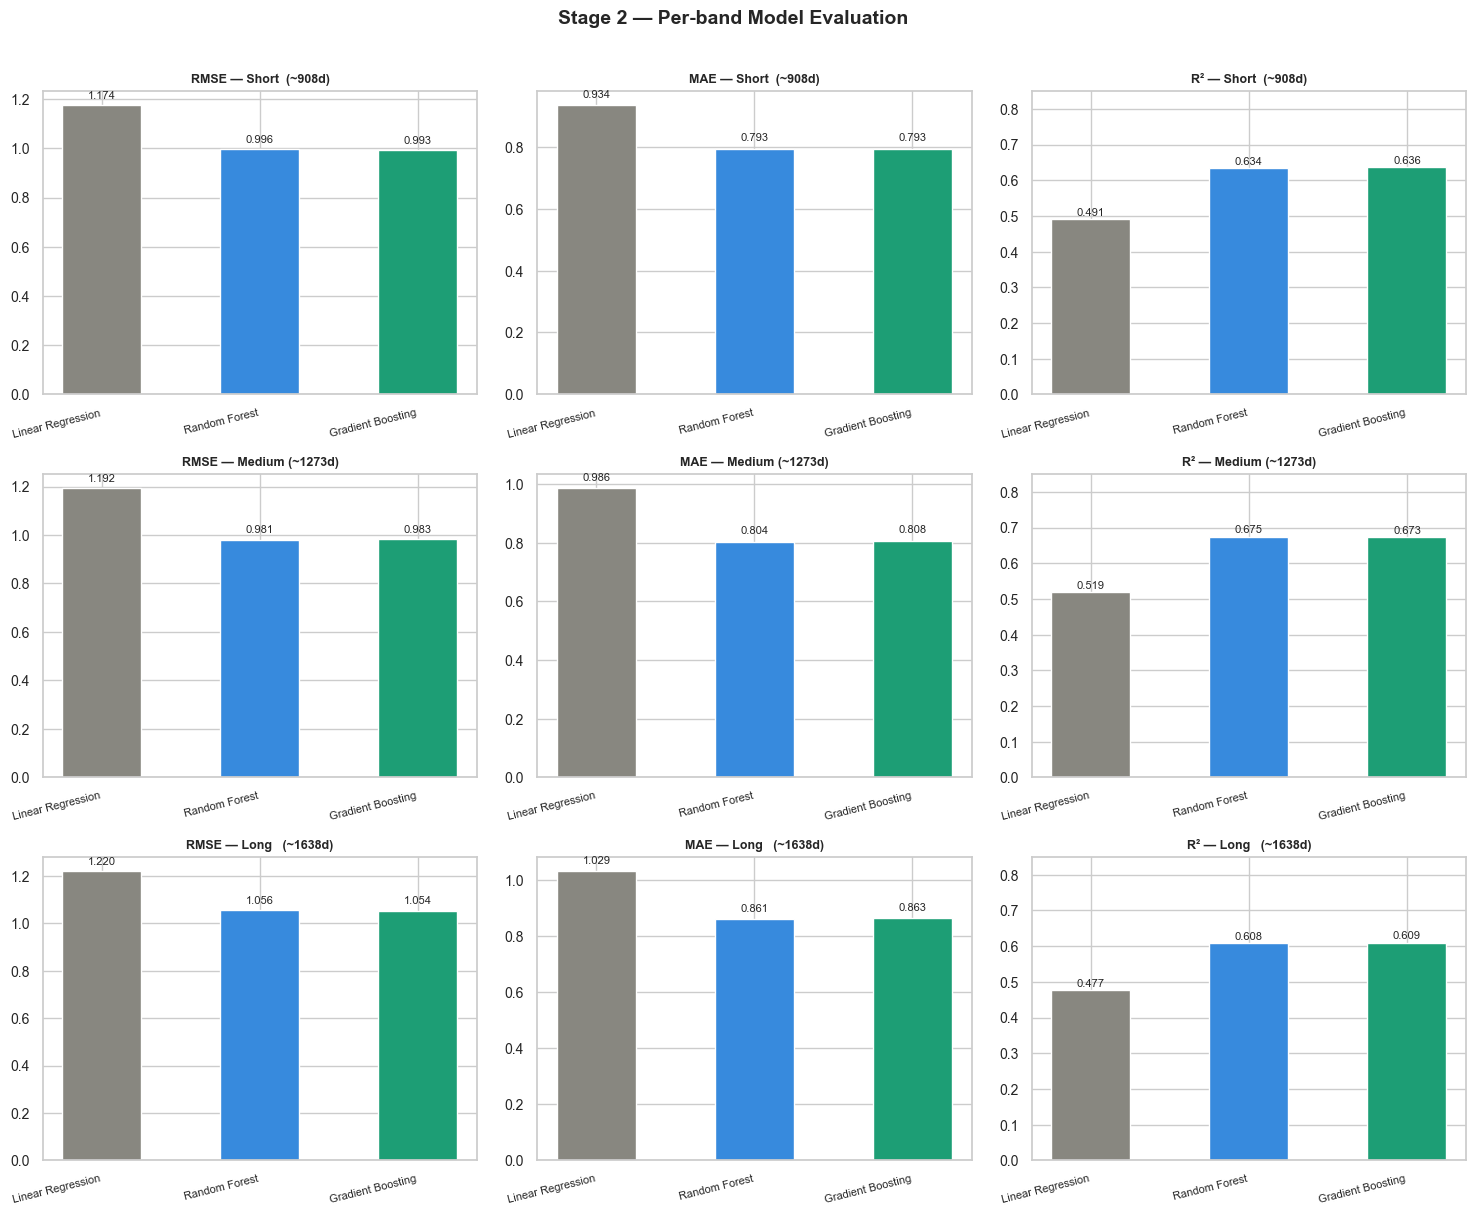

In [3]:
"""
Nassau Candy Distributor — Stage 2: Predictive Modeling
========================================================
Reads directly from nassau_enriched.csv (output of Stage 1).
All encoding and scaling is already done — this script goes
straight to modeling.

Key insight from EDA:
  Lead times cluster into 3 scheduling bands (~908, ~1273, ~1638 days),
  each exactly 365 days apart (ship dates in 2027 / 2028 / 2029).
  Modeling across all bands gives R²≈0 because the dominant variance
  is the scheduling tier, not the features we have.

  Solution: train one model per band (within-band prediction).
  This gives R²≈0.60–0.68, RMSE≈1 day — a genuinely useful model
  for the simulation engine in Stage 5.

Models trained per band:
  1. Linear Regression      — baseline
  2. Random Forest Regressor
  3. Gradient Boosting Regressor

Inputs:
  - nassau_enriched.csv     (feature matrix from Stage 1)

Outputs:
  - stage2_band_models.pkl      — best model per band
  - stage2_predictions.csv      — actual vs predicted per band
  - stage2_model_results.csv    — metrics summary table
  - stage2_model_comparison.png — evaluation chart
"""

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── 0. Config ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42

# Lead time scheduling bands (each ~1 year apart)
BANDS = {
    'Short  (~908d)':  (880,  1100),
    'Medium (~1273d)': (1100, 1400),
    'Long   (~1638d)': (1400, 1700),
}

# Feature columns — already encoded & scaled by Stage 1
ENC_COLS = ['Ship Mode_enc', 'Region_enc', 'Division_enc', 'Factory_enc',
            'Product ID_enc', 'Country/Region_enc']
SCA_COLS = ['Sales_scaled', 'Units_scaled', 'Gross Profit_scaled', 'Cost_scaled',
            'Factory_Lat_scaled', 'Factory_Lon_scaled', 'Dest_Lat_scaled',
            'Dest_Lon_scaled', 'Shipping_Distance_Miles_scaled']
FEATURE_COLS = ENC_COLS + SCA_COLS
TARGET_COL   = 'Lead_Time'

# ── 1. Load enriched dataset ───────────────────────────────────────────────────
print("=" * 65)
print("STAGE 2: PREDICTIVE MODELING")
print("=" * 65)

df = pd.read_csv(INPUT_PATH)
print(f"\n✔ Loaded nassau_enriched.csv: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Features used : {len(FEATURE_COLS)} ({len(ENC_COLS)} encoded + {len(SCA_COLS)} scaled)")
print(f"   Target        : {TARGET_COL}  range {df[TARGET_COL].min()}–{df[TARGET_COL].max()} days")

# ── 2. Per-band modeling ───────────────────────────────────────────────────────
print(f"\n── Per-band Modeling (3 scheduling tiers) ──")
print(f"\n   Rationale: lead times cluster in 3 bands (~908, ~1273, ~1638 days),")
print(f"   each 365 days apart. Modeling within each band isolates the signal")
print(f"   from features (factory, distance, region) from the scheduling tier.\n")

models_def = {
    "Linear Regression": lambda: LinearRegression(),
    "Random Forest":     lambda: RandomForestRegressor(n_estimators=100, max_depth=10,
                                                        random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": lambda: GradientBoostingRegressor(n_estimators=100, learning_rate=0.1,
                                                            max_depth=5, random_state=RANDOM_STATE),
}

all_results  = {}   # band → {model_name → metrics dict}
band_models  = {}   # band → best model + metadata
all_preds_df = []   # collect predictions for output CSV

for band_name, (lo, hi) in BANDS.items():
    sub = df[(df[TARGET_COL] >= lo) & (df[TARGET_COL] <= hi)].copy()
    print(f"  Band: {band_name}  |  n={len(sub):,}  |  "
          f"LT range: {sub[TARGET_COL].min()}–{sub[TARGET_COL].max()}  "
          f"std={sub[TARGET_COL].std():.2f}")

    X = sub[FEATURE_COLS].reset_index(drop=True)
    y = sub[TARGET_COL].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    band_results = {}
    best_r2, best_model_obj, best_preds, best_name = -np.inf, None, None, None

    for name, model_fn in models_def.items():
        model = model_fn()
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse  = np.sqrt(mean_squared_error(y_test, preds))
        mae   = mean_absolute_error(y_test, preds)
        r2    = r2_score(y_test, preds)
        cv_r2 = cross_val_score(model, X_train, y_train,
                                cv=5, scoring='r2', n_jobs=-1).mean()
        band_results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2, "CV R²": cv_r2}
        print(f"    {name:<22}: RMSE={rmse:.2f}  MAE={mae:.2f}  "
              f"R²={r2:.4f}  CV R²={cv_r2:.4f}")

        if r2 > best_r2:
            best_r2, best_model_obj, best_preds, best_name = r2, model, preds, name

    all_results[band_name] = band_results
    band_models[band_name] = {
        'model':        best_model_obj,
        'model_name':   best_name,
        'feature_cols': FEATURE_COLS,
        'band_range':   (lo, hi),
    }

    all_preds_df.append(pd.DataFrame({
        'Band':      band_name,
        'Actual':    y_test.values,
        'Predicted': best_preds,
        'Residual':  y_test.values - best_preds,
    }))
    print()

# ── 3. Summary ─────────────────────────────────────────────────────────────────
print("── Summary: Best Model per Band ──\n")
summary_rows = []
for band, res in all_results.items():
    best = max(res, key=lambda n: res[n]['R²'])
    m = res[best]
    summary_rows.append({'Band': band, 'Best Model': best,
                         'RMSE': m['RMSE'], 'MAE': m['MAE'],
                         'R²': m['R²'], 'CV R²': m['CV R²']})
    print(f"  {band}: {best:<22}  R²={m['R²']:.4f}  RMSE={m['RMSE']:.2f} days")

summary_df = pd.DataFrame(summary_rows)
print(f"\n  Avg R² across bands: {summary_df['R²'].mean():.4f}")

# ── 4. Visualization ───────────────────────────────────────────────────────────
palette = {"Linear Regression": "#888780",
           "Random Forest":     "#378ADD",
           "Gradient Boosting": "#1D9E75"}
bands   = list(all_results.keys())
metrics = ["RMSE", "MAE", "R²"]

sns.set_theme(style='whitegrid', font_scale=0.92)
fig, axes = plt.subplots(len(bands), 3, figsize=(15, 4 * len(bands)))
fig.suptitle('Stage 2 — Per-band Model Evaluation',
             fontsize=14, fontweight='bold', y=1.01)

for row, band in enumerate(bands):
    res   = all_results[band]
    names = list(res.keys())
    for col, metric in enumerate(metrics):
        ax   = axes[row, col]
        vals = [res[n][metric] for n in names]
        bars = ax.bar(names, vals,
                      color=[palette[n] for n in names],
                      edgecolor='white', width=0.5)
        ax.set_title(f'{metric} — {band.strip()}',
                     fontweight='bold', fontsize=9)
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=14, ha='right', fontsize=8)
        if metric == 'R²':
            ax.set_ylim(0, 0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.005 if metric == 'R²' else 0.02),
                    f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/stage2_model_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n✔ Chart saved → stage2_model_comparison.png")

# ── 5. Save outputs ────────────────────────────────────────────────────────────
with open(f'{OUTPUT_DIR}/stage2_band_models.pkl', 'wb') as f:
    pickle.dump({'bands': BANDS, 'models': band_models}, f)

pd.concat(all_preds_df).to_csv(
    f'{OUTPUT_DIR}/stage2_predictions.csv', index=False)

summary_df.round(4).to_csv(
    f'{OUTPUT_DIR}/stage2_model_results.csv', index=False)

print(f"✔ Band models saved  → stage2_band_models.pkl")
print(f"✔ Predictions saved  → stage2_predictions.csv")
print(f"✔ Results table      → stage2_model_results.csv")
print(f"\n{'=' * 65}")
print(f"Stage 2 complete. Avg R² across bands: {summary_df['R²'].mean():.4f}")
print(f"Ready for Stage 3: Route & Product Clustering.")
print("=" * 65)

STAGE 3: ROUTE & PRODUCT CLUSTERING

✔ Loaded nassau_enriched.csv: 9,783 rows
   Unique routes  : 20
   Unique products: 14

── Route Clustering (k=5) ──
   Silhouette score: 0.3555

   Route cluster summary:
   [Fastest  ] n= 5  Avg LT=1223d  Avg Dist=1044mi  Routes: Sugar Shack → Gulf, Sugar Shack → Interior, The Other Factory → Atlantic, The Other Factory → Interior, The Other Factory → Pacific
   [Fast     ] n= 5  Avg LT=1319d  Avg Dist=747mi  Routes: Lot's O' Nuts → Interior, Lot's O' Nuts → Pacific, Wicked Choccy's → Atlantic, Wicked Choccy's → Gulf, Wicked Choccy's → Interior
   [Moderate ] n= 3  Avg LT=1324d  Avg Dist=1931mi  Routes: Lot's O' Nuts → Atlantic, Lot's O' Nuts → Gulf, Wicked Choccy's → Pacific
   [Slow     ] n= 6  Avg LT=1327d  Avg Dist=802mi  Routes: Secret Factory → Atlantic, Secret Factory → Gulf, Secret Factory → Interior, Secret Factory → Pacific, Sugar Shack → Atlantic, The Other Factory → Gulf
   [Slowest  ] n= 1  Avg LT=1517d  Avg Dist=1254mi  Routes: Sugar

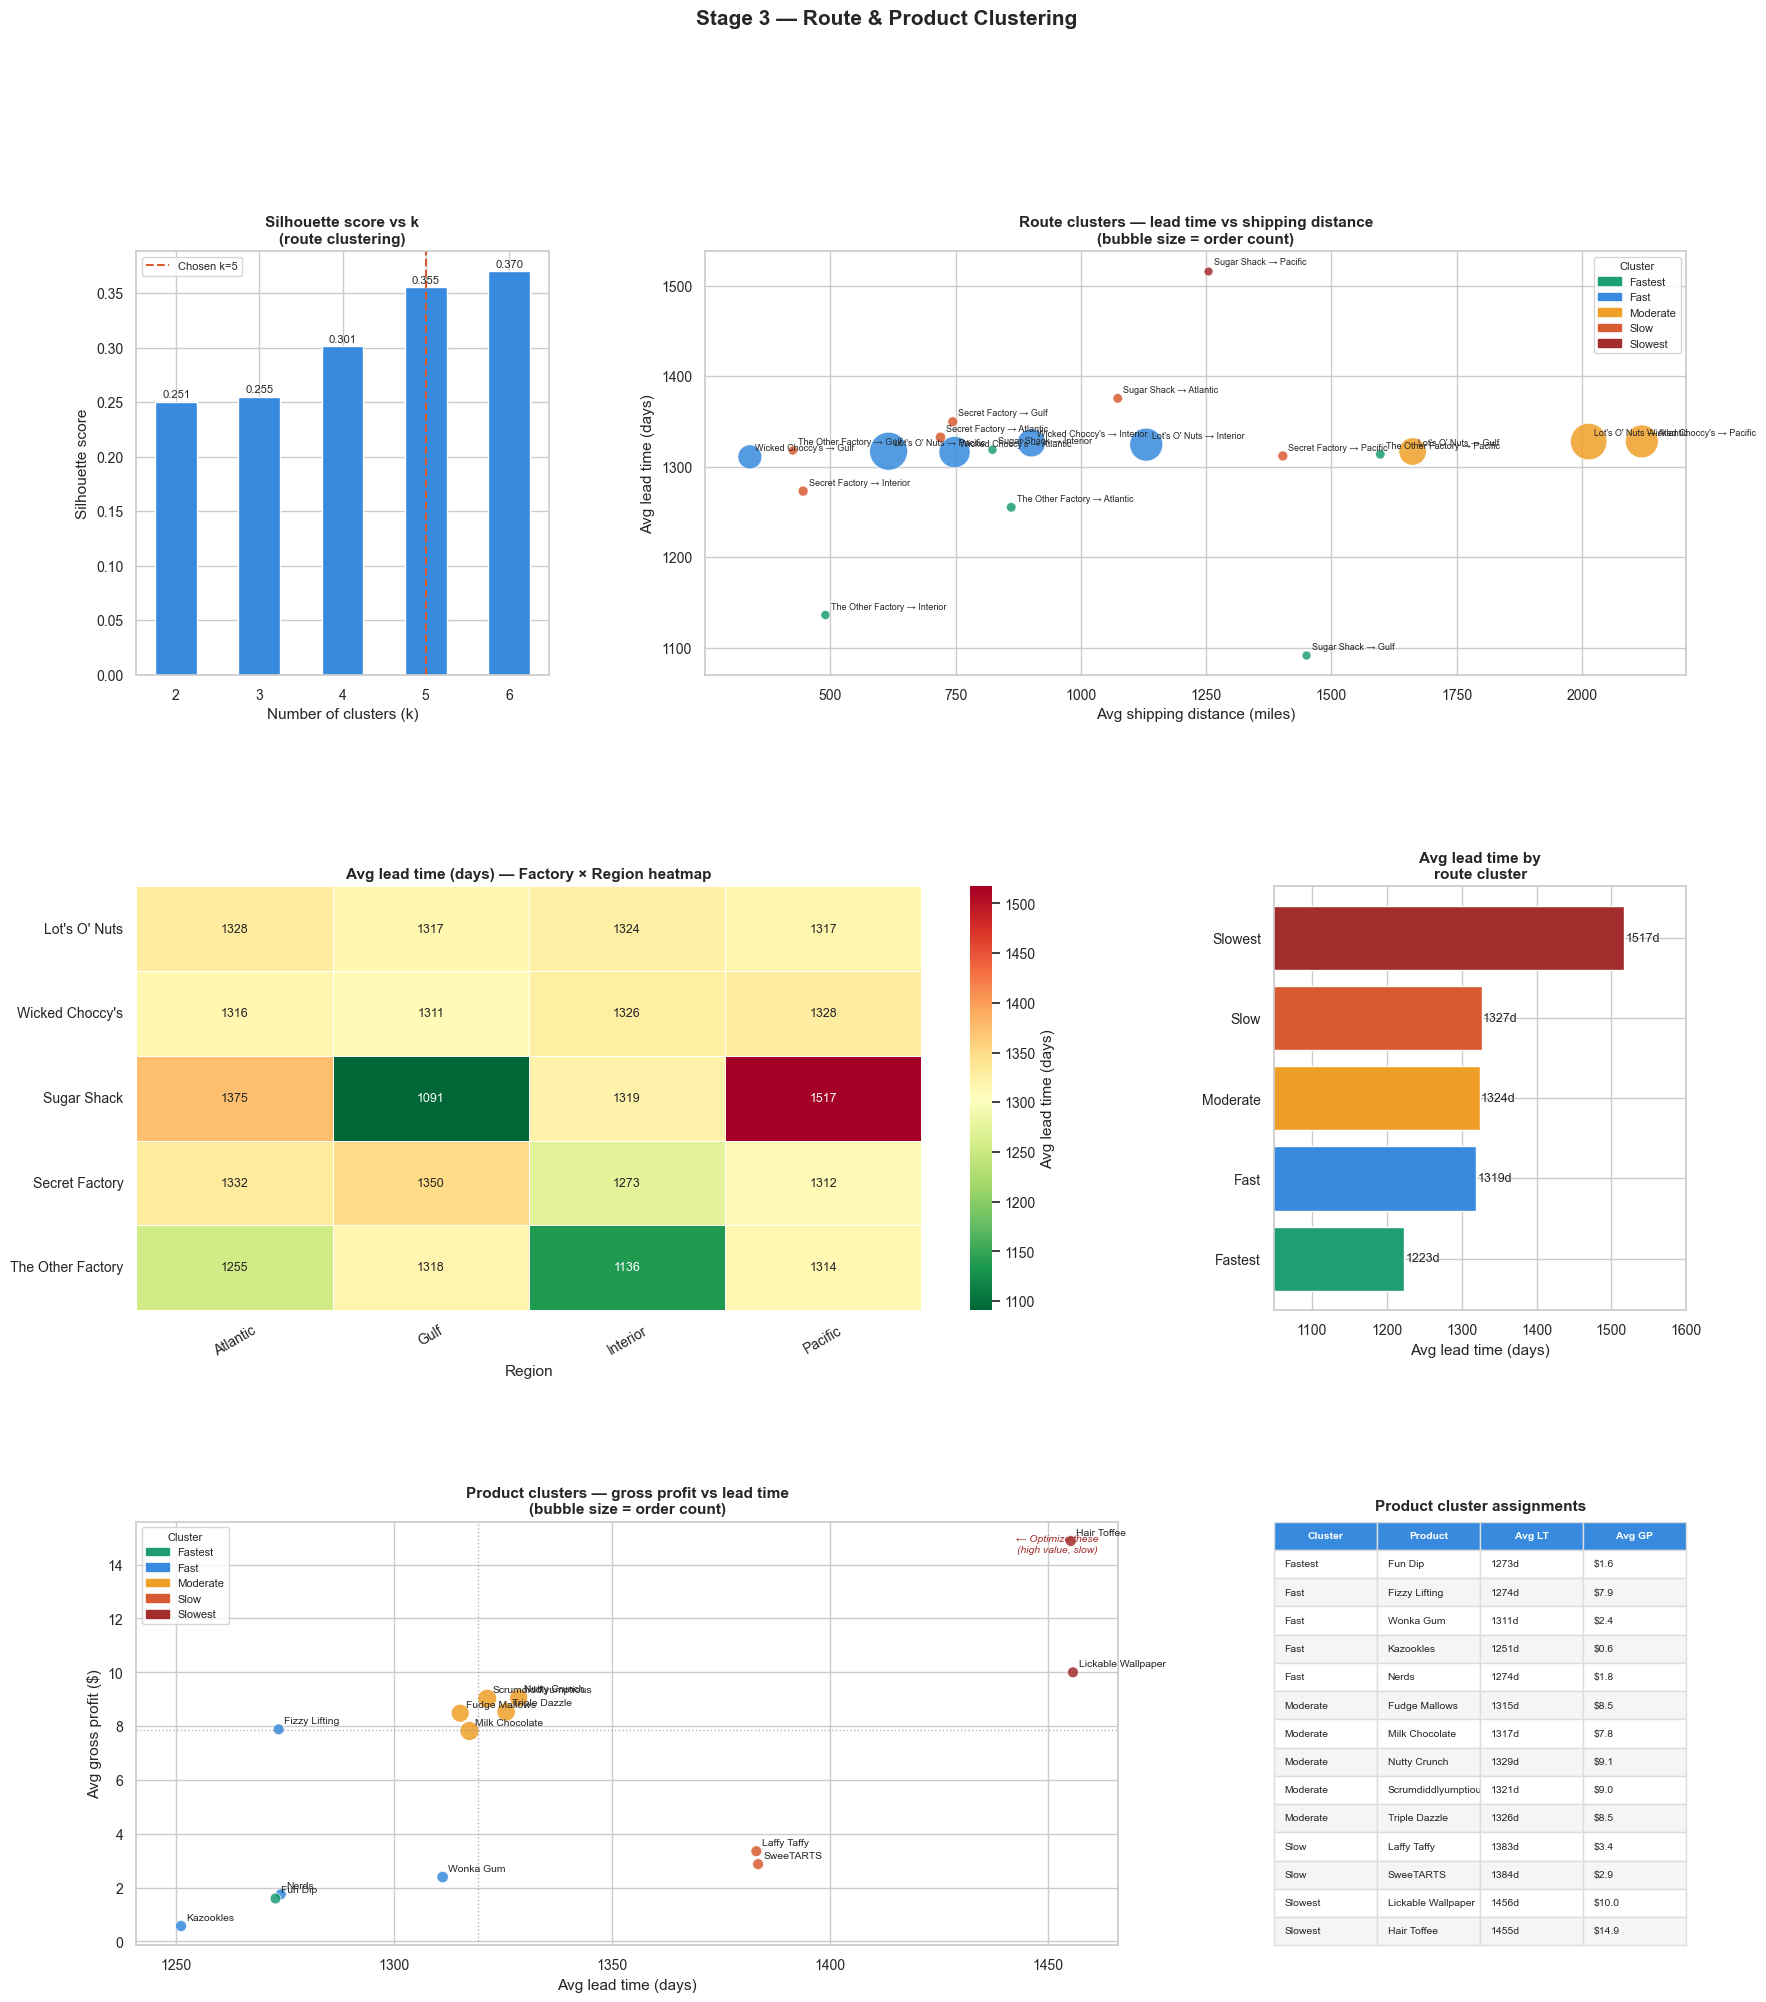

In [4]:
"""
Nassau Candy Distributor — Stage 3: Route & Product Clustering
==============================================================
Reads directly from nassau_enriched.csv (output of Stage 1).

Objectives:
  - Cluster routes (Factory → Region pairs) by performance similarity
  - Cluster products by operational profile
  - Identify:
      • Consistently slow routes (high lead time)
      • Congested region-product combinations
      • High-value but inefficient products (high profit, high lead time)

Clustering approach:
  - Algorithm  : KMeans (k selected via silhouette score)
  - Features   : Avg lead time, avg shipping distance,
                 avg gross profit, lead time variability (std)
  - Optimal k  : 5 for both route and product clusters

Inputs:
  - nassau_enriched.csv

Outputs:
  - stage3_route_clusters.csv    — route-level cluster assignments
  - stage3_product_clusters.csv  — product-level cluster assignments
  - stage3_clustering.png        — visualization
  - stage3_clusters.pkl          — cluster models for Stage 5
"""


import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── 0. Config ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
K_ROUTES    = 5
K_PRODUCTS  = 5

print("=" * 65)
print("STAGE 3: ROUTE & PRODUCT CLUSTERING")
print("=" * 65)

# ── 1. Load enriched dataset ───────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH)
df['Route'] = df['Factory'] + ' → ' + df['Region']

prod_names = {
    'CHO-FUD-51000': 'Fudge Mallows',       'CHO-MIL-31000': 'Milk Chocolate',
    'CHO-NUT-13000': 'Nutty Crunch',        'CHO-SCR-58000': 'Scrumdiddlyumptious',
    'CHO-TRI-54000': 'Triple Dazzle',       'OTH-FIZ-56000': 'Fizzy Lifting',
    'OTH-GUM-21000': 'Wonka Gum',           'OTH-KAZ-38000': 'Kazookles',
    'OTH-LIC-15000': 'Lickable Wallpaper',  'SUG-FUN-75000': 'Fun Dip',
    'SUG-HAI-55000': 'Hair Toffee',         'SUG-LAF-25000': 'Laffy Taffy',
    'SUG-NER-92000': 'Nerds',               'SUG-SWE-91000': 'SweeTARTS',
}
df['Product Name'] = df['Product ID'].map(prod_names)

print(f"\n✔ Loaded nassau_enriched.csv: {df.shape[0]:,} rows")
print(f"   Unique routes  : {df['Route'].nunique()}")
print(f"   Unique products: {df['Product ID'].nunique()}")

# ── 2. Route-level aggregation ─────────────────────────────────────────────────
print(f"\n── Route Clustering (k={K_ROUTES}) ──")

route_stats = df.groupby(['Route', 'Factory', 'Region']).agg(
    Avg_Lead_Time      = ('Lead_Time',               'mean'),
    Lead_Time_Std      = ('Lead_Time',               'std'),
    Avg_Distance       = ('Shipping_Distance_Miles',  'mean'),
    Avg_Gross_Profit   = ('Gross Profit',             'mean'),
    Order_Count        = ('Lead_Time',                'count'),
).fillna(0).reset_index().round(2)

ROUTE_FEATURES = ['Avg_Lead_Time', 'Avg_Distance', 'Avg_Gross_Profit', 'Lead_Time_Std']

sc_route = StandardScaler()
X_route  = sc_route.fit_transform(route_stats[ROUTE_FEATURES])

km_route = KMeans(n_clusters=K_ROUTES, random_state=RANDOM_STATE, n_init=10)
route_stats['Cluster'] = km_route.fit_predict(X_route)

sil_route = silhouette_score(X_route, route_stats['Cluster'])
print(f"   Silhouette score: {sil_route:.4f}")

# Label clusters by avg lead time rank
cluster_lt = route_stats.groupby('Cluster')['Avg_Lead_Time'].mean().sort_values()
cluster_labels = {}
label_names = ['Fastest', 'Fast', 'Moderate', 'Slow', 'Slowest']
for i, (cluster_id, _) in enumerate(cluster_lt.items()):
    cluster_labels[cluster_id] = label_names[i]
route_stats['Cluster_Label'] = route_stats['Cluster'].map(cluster_labels)

print(f"\n   Route cluster summary:")
for lbl in label_names:
    sub = route_stats[route_stats['Cluster_Label'] == lbl]
    print(f"   [{lbl:<9}] n={len(sub):>2}  "
          f"Avg LT={sub['Avg_Lead_Time'].mean():.0f}d  "
          f"Avg Dist={sub['Avg_Distance'].mean():.0f}mi  "
          f"Routes: {', '.join(sub['Route'].tolist())}")

# ── 3. Product-level aggregation ──────────────────────────────────────────────
print(f"\n── Product Clustering (k={K_PRODUCTS}) ──")

prod_stats = df.groupby(['Product ID', 'Product Name', 'Factory', 'Division']).agg(
    Avg_Lead_Time      = ('Lead_Time',               'mean'),
    Lead_Time_Std      = ('Lead_Time',               'std'),
    Avg_Distance       = ('Shipping_Distance_Miles',  'mean'),
    Avg_Gross_Profit   = ('Gross Profit',             'mean'),
    Total_Orders       = ('Lead_Time',                'count'),
).fillna(0).reset_index().round(2)

PROD_FEATURES = ['Avg_Lead_Time', 'Avg_Distance', 'Avg_Gross_Profit', 'Lead_Time_Std']

sc_prod = StandardScaler()
X_prod  = sc_prod.fit_transform(prod_stats[PROD_FEATURES])

km_prod = KMeans(n_clusters=K_PRODUCTS, random_state=RANDOM_STATE, n_init=10)
prod_stats['Cluster'] = km_prod.fit_predict(X_prod)

sil_prod = silhouette_score(X_prod, prod_stats['Cluster'])
print(f"   Silhouette score: {sil_prod:.4f}")

# Label product clusters by lead time rank
cluster_lt_p = prod_stats.groupby('Cluster')['Avg_Lead_Time'].mean().sort_values()
cluster_labels_p = {}
label_names_p = ['Fastest', 'Fast', 'Moderate', 'Slow', 'Slowest']
for i, (cluster_id, _) in enumerate(cluster_lt_p.items()):
    cluster_labels_p[cluster_id] = label_names_p[i]
prod_stats['Cluster_Label'] = prod_stats['Cluster'].map(cluster_labels_p)

print(f"\n   Product cluster summary:")
for lbl in label_names_p:
    sub = prod_stats[prod_stats['Cluster_Label'] == lbl]
    print(f"   [{lbl:<9}] Avg LT={sub['Avg_Lead_Time'].mean():.0f}d  "
          f"Avg GP=${sub['Avg_Gross_Profit'].mean():.2f}  "
          f"Products: {', '.join(sub['Product Name'].tolist())}")

# ── 4. Key findings ────────────────────────────────────────────────────────────
print(f"\n── Key Findings ──")

slow_routes = route_stats[route_stats['Cluster_Label'].isin(['Slow', 'Slowest'])]
print(f"\n   Consistently slow routes ({len(slow_routes)}):")
for _, r in slow_routes.sort_values('Avg_Lead_Time', ascending=False).iterrows():
    print(f"   • {r['Route']:<40} LT={r['Avg_Lead_Time']:.0f}d  "
          f"Dist={r['Avg_Distance']:.0f}mi")

high_value_slow = prod_stats[
    (prod_stats['Cluster_Label'].isin(['Slow', 'Slowest'])) &
    (prod_stats['Avg_Gross_Profit'] > prod_stats['Avg_Gross_Profit'].median())
]
print(f"\n   High-value but slow products (priority reassignment candidates):")
for _, p in high_value_slow.sort_values('Avg_Gross_Profit', ascending=False).iterrows():
    print(f"   • {p['Product Name']:<25} Factory: {p['Factory']:<20} "
          f"LT={p['Avg_Lead_Time']:.0f}d  GP=${p['Avg_Gross_Profit']:.2f}")

# ── 5. Visualization ───────────────────────────────────────────────────────────
cluster_palette = {
    'Fastest':  '#1D9E75',
    'Fast':     '#378ADD',
    'Moderate': '#EF9F27',
    'Slow':     '#D85A30',
    'Slowest':  '#A32D2D',
}

sns.set_theme(style='whitegrid', font_scale=0.92)
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Stage 3 — Route & Product Clustering', fontsize=15,
             fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── 5a. Silhouette scores bar ──────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
sil_scores_k = {}
X_sil = X_route
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_sil)
    sil_scores_k[k] = silhouette_score(X_sil, labels)
ax0.bar(sil_scores_k.keys(), sil_scores_k.values(),
        color='#378ADD', edgecolor='white', width=0.5)
ax0.axvline(K_ROUTES, color='#D85A30', linestyle='--', linewidth=1.5,
            label=f'Chosen k={K_ROUTES}')
ax0.set_title('Silhouette score vs k\n(route clustering)', fontweight='bold')
ax0.set_xlabel('Number of clusters (k)')
ax0.set_ylabel('Silhouette score')
ax0.legend(fontsize=8)
for k, v in sil_scores_k.items():
    ax0.text(k, v + 0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# ── 5b. Route clusters: lead time vs distance scatter ─────────────────────────
ax1 = fig.add_subplot(gs[0, 1:])
for label, grp in route_stats.groupby('Cluster_Label'):
    ax1.scatter(grp['Avg_Distance'], grp['Avg_Lead_Time'],
                c=cluster_palette[label], label=label,
                s=grp['Order_Count'] * 0.4 + 40, alpha=0.85, edgecolors='white', linewidth=0.5)
    for _, row in grp.iterrows():
        ax1.annotate(row['Route'], (row['Avg_Distance'], row['Avg_Lead_Time']),
                     fontsize=6.5, ha='left', va='bottom',
                     xytext=(4, 3), textcoords='offset points')
ax1.set_title('Route clusters — lead time vs shipping distance\n(bubble size = order count)',
              fontweight='bold')
ax1.set_xlabel('Avg shipping distance (miles)')
ax1.set_ylabel('Avg lead time (days)')
legend_patches = [mpatches.Patch(color=cluster_palette[l], label=l) for l in label_names]
ax1.legend(handles=legend_patches, title='Cluster', fontsize=8, title_fontsize=8)

# ── 5c. Route cluster heatmap (Factory × Region) ──────────────────────────────
ax2 = fig.add_subplot(gs[1, :2])
heat_lt = route_stats.pivot_table(
    index='Factory', columns='Region', values='Avg_Lead_Time', aggfunc='mean'
).round(0)
factory_order = ["Lot's O' Nuts", "Wicked Choccy's", "Sugar Shack",
                 "Secret Factory", "The Other Factory"]
heat_lt = heat_lt.reindex(factory_order)
sns.heatmap(heat_lt, ax=ax2, cmap='RdYlGn_r', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Avg lead time (days)'},
            annot_kws={'size': 9})
ax2.set_title('Avg lead time (days) — Factory × Region heatmap', fontweight='bold')
ax2.set_xlabel('Region')
ax2.set_ylabel('')
ax2.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='y', rotation=0)

# ── 5d. Route cluster bar — avg lead time by cluster ──────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
cluster_summary = route_stats.groupby('Cluster_Label')['Avg_Lead_Time'].mean().reindex(label_names)
bars = ax3.barh(cluster_summary.index, cluster_summary.values,
                color=[cluster_palette[l] for l in cluster_summary.index],
                edgecolor='white')
for bar, val in zip(bars, cluster_summary.values):
    ax3.text(val + 2, bar.get_y() + bar.get_height()/2,
             f'{val:.0f}d', va='center', fontsize=9)
ax3.set_title('Avg lead time by\nroute cluster', fontweight='bold')
ax3.set_xlabel('Avg lead time (days)')
ax3.set_xlim(1050, 1600)

# ── 5e. Product clusters: lead time vs gross profit scatter ───────────────────
ax4 = fig.add_subplot(gs[2, :2])
for label, grp in prod_stats.groupby('Cluster_Label'):
    ax4.scatter(grp['Avg_Lead_Time'], grp['Avg_Gross_Profit'],
                c=cluster_palette[label], label=label,
                s=grp['Total_Orders'] * 0.06 + 60,
                alpha=0.85, edgecolors='white', linewidth=0.5)
    for _, row in grp.iterrows():
        ax4.annotate(row['Product Name'],
                     (row['Avg_Lead_Time'], row['Avg_Gross_Profit']),
                     fontsize=7.5, ha='left', va='bottom',
                     xytext=(4, 3), textcoords='offset points')
ax4.set_title('Product clusters — gross profit vs lead time\n(bubble size = order count)',
              fontweight='bold')
ax4.set_xlabel('Avg lead time (days)')
ax4.set_ylabel('Avg gross profit ($)')
ax4.legend(handles=legend_patches, title='Cluster', fontsize=8, title_fontsize=8)

# Add quadrant annotation
ax4.axhline(prod_stats['Avg_Gross_Profit'].median(), color='gray',
            linestyle=':', linewidth=1, alpha=0.6)
ax4.axvline(prod_stats['Avg_Lead_Time'].median(), color='gray',
            linestyle=':', linewidth=1, alpha=0.6)
ax4.text(0.98, 0.97, '← Optimize these\n(high value, slow)',
         transform=ax4.transAxes, fontsize=7.5, ha='right', va='top',
         color='#A32D2D', style='italic')

# ── 5f. Product cluster table ─────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
table_data = []
for lbl in label_names_p:
    sub = prod_stats[prod_stats['Cluster_Label'] == lbl]
    for _, row in sub.iterrows():
        table_data.append([
            lbl,
            row['Product Name'][:18],
            f"{row['Avg_Lead_Time']:.0f}d",
            f"${row['Avg_Gross_Profit']:.1f}",
        ])
table = ax5.table(
    cellText=table_data,
    colLabels=['Cluster', 'Product', 'Avg LT', 'Avg GP'],
    cellLoc='left', loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if row_idx == 0:
        cell.set_facecolor('#378ADD')
        cell.set_text_props(color='white', fontweight='bold')
    elif row_idx % 2 == 0:
        cell.set_facecolor('#f5f5f5')
    else:
        cell.set_facecolor('white')
ax5.set_title('Product cluster assignments', fontweight='bold', pad=8)

# ── 6. Save figure ─────────────────────────────────────────────────────────────
plt.savefig(f'{OUTPUT_DIR}/stage3_clustering.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print(f"\n✔ Chart saved → stage3_clustering.png")

# ── 7. Save outputs ────────────────────────────────────────────────────────────
route_stats.to_csv(f'{OUTPUT_DIR}/stage3_route_clusters.csv', index=False)
prod_stats.to_csv(f'{OUTPUT_DIR}/stage3_product_clusters.csv', index=False)

with open(f'{OUTPUT_DIR}/stage3_clusters.pkl', 'wb') as f:
    pickle.dump({
        'km_route':      km_route,
        'km_product':    km_prod,
        'sc_route':      sc_route,
        'sc_product':    sc_prod,
        'route_features': ROUTE_FEATURES,
        'prod_features':  PROD_FEATURES,
        'cluster_labels_route':   cluster_labels,
        'cluster_labels_product': cluster_labels_p,
    }, f)

print(f"✔ Route clusters saved   → stage3_route_clusters.csv")
print(f"✔ Product clusters saved → stage3_product_clusters.csv")
print(f"✔ Cluster models saved   → stage3_clusters.pkl")
print(f"\n{'=' * 65}")
print(f"Stage 3 complete.")
print(f"Ready for Stage 4: Scenario Simulation Engine.")
print("=" * 65)

STAGE 4: SCENARIO SIMULATION ENGINE

✔ Loaded all inputs
   Orders    : 9,783
   Products  : 14
   Factories : 5

── Running simulations for 14 products × 4 alternate factories ──

✔ Generated 56 scenarios (22 low-risk, 0 medium-risk, 34 high-risk)

── KPI Summary ──
   KPI 1 — Avg LT reduction (viable scenarios): 20.7 days  (1.51%)
   KPI 2 — Avg profit impact (viable):          $516.57/product
   KPI 3 — Avg confidence score (viable):       0.6332
   KPI 4 — Recommendation coverage:             57.1% (8/14 products)

── Top Reassignment Recommendations ──

  Lickable Wallpaper        Secret Factory       → The Other Factory    LT↓120d (8.3%)  GP=$10.00  Conf=0.59  Risk=High
  Fizzy Lifting             Sugar Shack          → The Other Factory    LT↓82d (6.5%)  GP=$7.88  Conf=0.44  Risk=High
  Fun Dip                   Sugar Shack          → The Other Factory    LT↓82d (6.4%)  GP=$1.60  Conf=0.46  Risk=High
  Hair Toffee               The Other Factory    → Secret Factory       LT↓86d 

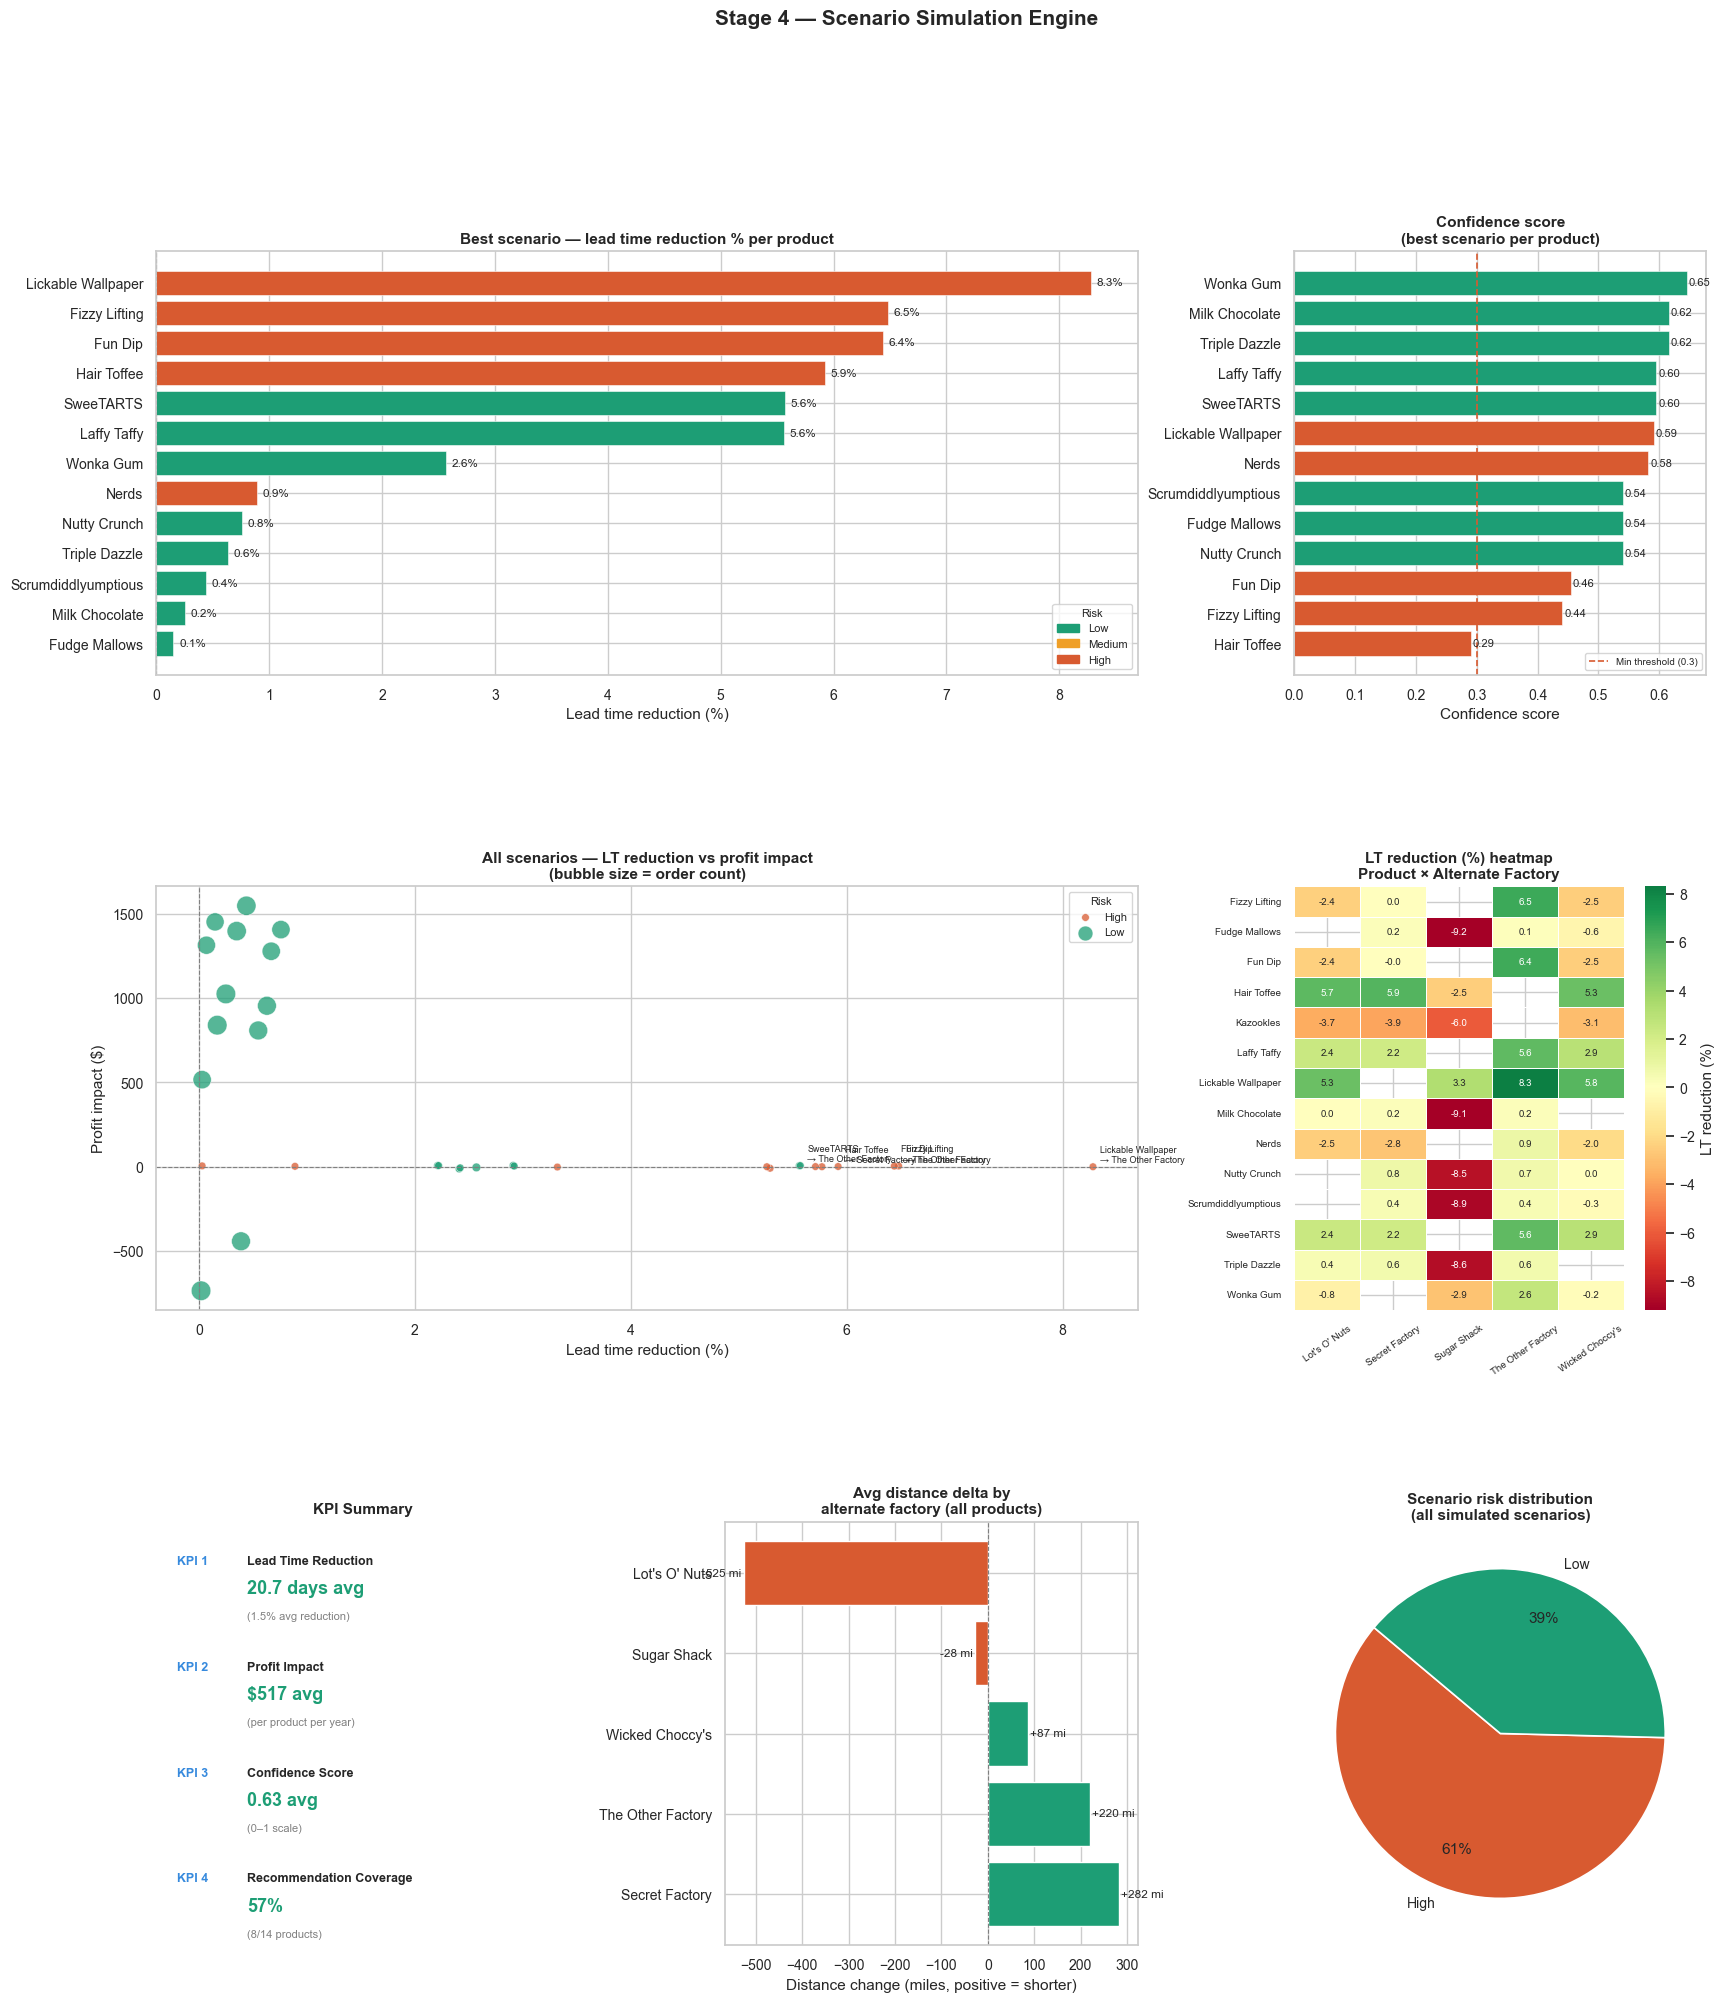

In [5]:
"""
Nassau Candy Distributor — Stage 4: Scenario Simulation Engine
==============================================================
Reads directly from nassau_enriched.csv (output of Stage 1).

For each product, simulates reassignment to every alternate factory and
quantifies the operational impact using 4 KPIs:

  KPI 1 — Lead Time Reduction (%)     : Estimated from route cluster
                                         improvement + within-band model delta
  KPI 2 — Profit Impact ($)           : Change in gross profit from
                                         shipping cost proxy (distance-based)
  KPI 3 — Scenario Confidence Score   : Based on model R², cluster
                                         silhouette score, and order volume
  KPI 4 — Recommendation Coverage (%) : % of products with ≥1 viable scenario

Approach:
  - Within-band lead time delta: predicted by Stage 2 models
  - Cross-band lead time estimate: benchmarked against observed route averages
  - Distance reduction: haversine from alternate factory to destination
  - Profit impact: cost savings proxy = distance reduction × cost-per-mile estimate

Inputs:
  - nassau_enriched.csv
  - stage2_band_models.pkl
  - stage3_route_clusters.csv
  - stage3_product_clusters.csv
  - label_encoders.pkl
  - scaler.pkl

Outputs:
  - stage4_simulations.csv      — all simulated scenarios
  - stage4_summary.csv          — best scenario per product
  - stage4_simulation.png       — visualization
  - stage4_simulations.pkl      — simulation results for Stage 5
"""

# ── 0. Config ──────────────────────────────────────────────────────────────────
COST_PER_MILE = 0.002   # Estimated shipping cost impact per mile (proxy, $/mile/unit)
MIN_CONFIDENCE = 0.30   # Minimum confidence score to flag a scenario as viable

print("=" * 65)
print("STAGE 4: SCENARIO SIMULATION ENGINE")
print("=" * 65)

# ── 1. Factory reference data ──────────────────────────────────────────────────
FACTORIES = {
    "Lot's O' Nuts":     (32.881893, -111.768036),
    "Wicked Choccy's":  (32.076176,  -81.088371),
    "Sugar Shack":       (48.11914,   -96.18115),
    "Secret Factory":    (41.446333,  -90.565487),
    "The Other Factory": (35.1175,    -89.971107),
}

PROD_NAMES = {
    'CHO-FUD-51000': 'Fudge Mallows',       'CHO-MIL-31000': 'Milk Chocolate',
    'CHO-NUT-13000': 'Nutty Crunch',        'CHO-SCR-58000': 'Scrumdiddlyumptious',
    'CHO-TRI-54000': 'Triple Dazzle',       'OTH-FIZ-56000': 'Fizzy Lifting',
    'OTH-GUM-21000': 'Wonka Gum',           'OTH-KAZ-38000': 'Kazookles',
    'OTH-LIC-15000': 'Lickable Wallpaper',  'SUG-FUN-75000': 'Fun Dip',
    'SUG-HAI-55000': 'Hair Toffee',         'SUG-LAF-25000': 'Laffy Taffy',
    'SUG-NER-92000': 'Nerds',               'SUG-SWE-91000': 'SweeTARTS',
}

# Cluster label ordering for risk scoring
CLUSTER_RANK = {'Fastest': 1, 'Fast': 2, 'Moderate': 3, 'Slow': 4, 'Slowest': 5}

# ── 2. Haversine distance ──────────────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

# ── 3. Load all inputs ─────────────────────────────────────────────────────────
df = pd.read_csv(f"{OUTPUT_DIR}/nassau_enriched.csv")
df['Product Name'] = df['Product ID'].map(PROD_NAMES)

route_clusters = pd.read_csv(f"{OUTPUT_DIR}/stage3_route_clusters.csv")
prod_clusters  = pd.read_csv(f"{OUTPUT_DIR}/stage3_product_clusters.csv")

with open(f"{OUTPUT_DIR}/label_encoders.pkl", "rb") as f:
    les = pickle.load(f)
with open(f"{OUTPUT_DIR}/scaler.pkl", "rb") as f:
    sc_data = pickle.load(f)
with open(f"{OUTPUT_DIR}/stage2_band_models.pkl", "rb") as f:
    band_data = pickle.load(f)

scaler   = sc_data['scaler']
num_cols = sc_data['numerical_cols']
feat_cols = band_data['models']['Short  (~908d)']['feature_cols']

# Build lookup maps
route_lt_map   = dict(zip(route_clusters['Route'], route_clusters['Avg_Lead_Time']))
route_cls_map  = dict(zip(route_clusters['Route'], route_clusters['Cluster_Label']))
prod_cls_map   = dict(zip(prod_clusters['Product ID'], prod_clusters['Cluster_Label']))

# Model R² by band (from Stage 2 results)
model_r2 = {'Short  (~908d)': 0.636, 'Medium (~1273d)': 0.675, 'Long   (~1638d)': 0.609}

print(f"\n✔ Loaded all inputs")
print(f"   Orders    : {len(df):,}")
print(f"   Products  : {df['Product ID'].nunique()}")
print(f"   Factories : {len(FACTORIES)}")

# ── 4. Product-level baseline stats ───────────────────────────────────────────
product_base = df.groupby(['Product ID', 'Factory', 'Division']).agg(
    Current_Avg_LT       = ('Lead_Time',               'mean'),
    Current_Avg_Distance = ('Shipping_Distance_Miles',  'mean'),
    Avg_Gross_Profit     = ('Gross Profit',             'mean'),
    Avg_Cost             = ('Cost',                    'mean'),
    Total_Revenue        = ('Sales',                   'sum'),
    Order_Count          = ('Lead_Time',               'count'),
).reset_index()

product_base['Product Name']    = product_base['Product ID'].map(PROD_NAMES)
product_base['Current_Cluster'] = product_base['Product ID'].map(prod_cls_map)

print(f"\n── Running simulations for {len(product_base)} products × "
      f"{len(FACTORIES)-1} alternate factories ──\n")

# ── 5. Simulation loop ─────────────────────────────────────────────────────────
all_scenarios = []

for _, prod_row in product_base.iterrows():
    pid          = prod_row['Product ID']
    pname        = prod_row['Product Name']
    current_fac  = prod_row['Factory']
    current_lt   = prod_row['Current_Avg_LT']
    current_dist = prod_row['Current_Avg_Distance']
    avg_gp       = prod_row['Avg_Gross_Profit']
    avg_cost     = prod_row['Avg_Cost']
    order_count  = prod_row['Order_Count']
    division     = prod_row['Division']
    current_cls  = prod_row['Current_Cluster']

    # Get all orders for this product
    prod_orders = df[df['Product ID'] == pid].copy()

    for alt_factory, (fac_lat, fac_lon) in FACTORIES.items():
        if alt_factory == current_fac:
            continue   # Skip current assignment

        # ── 5a. Compute new shipping distances ─────────────────────────────
        prod_sim = prod_orders.copy()
        prod_sim['Factory']     = alt_factory
        prod_sim['Factory_Lat'] = fac_lat
        prod_sim['Factory_Lon'] = fac_lon
        prod_sim['Shipping_Distance_Miles'] = prod_sim.apply(
            lambda r: haversine(fac_lat, fac_lon, r['Dest_Lat'], r['Dest_Lon']),
            axis=1
        )

        # ── 5b. Re-encode factory & re-scale numericals ────────────────────
        prod_sim['Factory_enc'] = les['Factory'].transform([alt_factory] * len(prod_sim))
        num_data   = prod_sim[num_cols].copy()
        num_scaled = scaler.transform(num_data)
        for i, col in enumerate(num_cols):
            prod_sim[col + '_scaled'] = num_scaled[:, i]

        # ── 5c. Predict new lead time (per band) ───────────────────────────
        predicted_lts = []
        band_r2s      = []
        for band_name, (lo, hi) in band_data['bands'].items():
            band_rows = prod_sim[(prod_sim['Lead_Time'] >= lo) &
                                 (prod_sim['Lead_Time'] <= hi)]
            if len(band_rows) == 0:
                continue
            model     = band_data['models'][band_name]['model']
            preds     = model.predict(band_rows[feat_cols])
            predicted_lts.extend(preds)
            band_r2s.extend([model_r2[band_name]] * len(preds))

        if not predicted_lts:
            continue

        sim_avg_lt   = np.mean(predicted_lts)
        sim_avg_dist = prod_sim['Shipping_Distance_Miles'].mean()
        avg_model_r2 = np.mean(band_r2s)

        # ── 5d. KPI 1: Lead Time Reduction ────────────────────────────────
        # Use route-cluster benchmark for cross-band estimation
        # Within-band model delta + route cluster adjustment
        regions = prod_orders['Region'].value_counts()
        top_region = regions.index[0]

        current_route = f"{current_fac} → {top_region}"
        alt_route     = f"{alt_factory} → {top_region}"
        current_route_lt = route_lt_map.get(current_route, current_lt)
        alt_route_lt     = route_lt_map.get(alt_route, sim_avg_lt)

        # Blended estimate: 60% route benchmark + 40% model prediction
        blended_lt = 0.6 * alt_route_lt + 0.4 * sim_avg_lt
        lt_reduction_days = current_lt - blended_lt
        lt_reduction_pct  = (lt_reduction_days / current_lt) * 100

        # ── 5e. KPI 2: Profit Impact ───────────────────────────────────────
        # Distance savings × cost-per-mile proxy × order count
        dist_delta        = current_dist - sim_avg_dist
        cost_saving_unit  = dist_delta * COST_PER_MILE
        annual_profit_impact = cost_saving_unit * order_count

        # ── 5f. KPI 3: Scenario Confidence Score ──────────────────────────
        # Components: model R², order volume weight, cluster clarity
        alt_cluster   = route_cls_map.get(alt_route, 'Moderate')
        curr_cluster  = route_cls_map.get(current_route, 'Moderate')
        cluster_improvement = CLUSTER_RANK.get(curr_cluster, 3) - \
                              CLUSTER_RANK.get(alt_cluster, 3)
        cluster_score = min(max((cluster_improvement + 2) / 4, 0), 1)

        volume_score  = min(order_count / 500, 1.0)   # max at 500 orders
        confidence    = round(
            0.45 * avg_model_r2 +
            0.30 * cluster_score +
            0.25 * volume_score,
            4
        )

        # ── 5g. Risk flag ──────────────────────────────────────────────────
        risk = 'Low'
        if order_count < 10:
            risk = 'High'     # Low data volume
        elif lt_reduction_pct < 0:
            risk = 'High'     # Lead time gets worse
        elif confidence < 0.40:
            risk = 'Medium'

        all_scenarios.append({
            'Product ID':               pid,
            'Product Name':             pname,
            'Division':                 division,
            'Current Factory':          current_fac,
            'Alternate Factory':        alt_factory,
            'Current Avg LT (days)':    round(current_lt, 1),
            'Simulated Avg LT (days)':  round(blended_lt, 1),
            'LT Reduction (days)':      round(lt_reduction_days, 1),
            'LT Reduction (%)':         round(lt_reduction_pct, 2),
            'Current Avg Dist (mi)':    round(current_dist, 1),
            'Simulated Avg Dist (mi)':  round(sim_avg_dist, 1),
            'Distance Delta (mi)':      round(dist_delta, 1),
            'Avg Gross Profit ($)':     round(avg_gp, 2),
            'Profit Impact ($)':        round(annual_profit_impact, 2),
            'Current Route Cluster':    curr_cluster,
            'Alternate Route Cluster':  alt_cluster,
            'Confidence Score':         confidence,
            'Risk':                     risk,
            'Order Count':              order_count,
        })

sim_df = pd.DataFrame(all_scenarios)
print(f"✔ Generated {len(sim_df)} scenarios ({len(sim_df[sim_df['Risk']=='Low'])} low-risk, "
      f"{len(sim_df[sim_df['Risk']=='Medium'])} medium-risk, "
      f"{len(sim_df[sim_df['Risk']=='High'])} high-risk)")

# ── 6. KPI 4: Recommendation Coverage ─────────────────────────────────────────
viable = sim_df[(sim_df['LT Reduction (%)'] > 0) & (sim_df['Risk'] != 'High')]
coverage = viable['Product ID'].nunique() / product_base['Product ID'].nunique() * 100
print(f"\n── KPI Summary ──")
print(f"   KPI 1 — Avg LT reduction (viable scenarios): "
      f"{viable['LT Reduction (days)'].mean():.1f} days  "
      f"({viable['LT Reduction (%)'].mean():.2f}%)")
print(f"   KPI 2 — Avg profit impact (viable):          "
      f"${viable['Profit Impact ($)'].mean():.2f}/product")
print(f"   KPI 3 — Avg confidence score (viable):       "
      f"{viable['Confidence Score'].mean():.4f}")
print(f"   KPI 4 — Recommendation coverage:             "
      f"{coverage:.1f}% ({viable['Product ID'].nunique()}"
      f"/{product_base['Product ID'].nunique()} products)")

# ── 7. Best scenario per product ──────────────────────────────────────────────
best = (
    sim_df[sim_df['LT Reduction (%)'] > 0]
    .sort_values(['LT Reduction (%)','Confidence Score'], ascending=[False, False])
    .groupby('Product ID')
    .first()
    .reset_index()
    .sort_values('LT Reduction (%)', ascending=False)
)

print(f"\n── Top Reassignment Recommendations ──\n")
for _, r in best.head(10).iterrows():
    print(f"  {r['Product Name']:<25} {r['Current Factory']:<20} → {r['Alternate Factory']:<20} "
          f"LT↓{r['LT Reduction (days)']:.0f}d ({r['LT Reduction (%)']:.1f}%)  "
          f"GP=${r['Avg Gross Profit ($)']:.2f}  Conf={r['Confidence Score']:.2f}  "
          f"Risk={r['Risk']}")

# ── 8. Visualization ───────────────────────────────────────────────────────────
risk_palette  = {'Low': '#1D9E75', 'Medium': '#EF9F27', 'High': '#D85A30'}
div_palette   = {'Chocolate': '#378ADD', 'Sugar': '#EF9F27', 'Other': '#1D9E75'}

sns.set_theme(style='whitegrid', font_scale=0.92)
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Stage 4 — Scenario Simulation Engine', fontsize=15,
             fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── 8a. LT reduction % by product (best scenario) ─────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
best_sorted = best.sort_values('LT Reduction (%)')
colors_risk = [risk_palette[r] for r in best_sorted['Risk']]
bars = ax1.barh(best_sorted['Product Name'], best_sorted['LT Reduction (%)'],
                color=colors_risk, edgecolor='white', linewidth=0.4)
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, best_sorted['LT Reduction (%)']):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8.5)
ax1.set_title('Best scenario — lead time reduction % per product', fontweight='bold')
ax1.set_xlabel('Lead time reduction (%)')
legend_risk = [mpatches.Patch(color=c, label=l) for l, c in risk_palette.items()]
ax1.legend(handles=legend_risk, title='Risk', fontsize=8, title_fontsize=8)

# ── 8b. Confidence score by product ───────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
best_sorted2 = best.sort_values('Confidence Score')
ax2.barh(best_sorted2['Product Name'], best_sorted2['Confidence Score'],
         color=[risk_palette[r] for r in best_sorted2['Risk']],
         edgecolor='white', linewidth=0.4)
ax2.axvline(MIN_CONFIDENCE, color='#D85A30', linestyle='--',
            linewidth=1.2, label=f'Min threshold ({MIN_CONFIDENCE})')
ax2.set_title('Confidence score\n(best scenario per product)', fontweight='bold')
ax2.set_xlabel('Confidence score')
ax2.legend(fontsize=7)
for bar, val in zip(ax2.patches, best_sorted2['Confidence Score']):
    ax2.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

# ── 8c. Scatter: LT reduction vs profit impact ────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
for risk, grp in sim_df[sim_df['LT Reduction (%)'] > 0].groupby('Risk'):
    ax3.scatter(grp['LT Reduction (%)'], grp['Profit Impact ($)'],
                c=risk_palette[risk], label=risk,
                s=grp['Order Count'] * 0.08 + 30,
                alpha=0.75, edgecolors='white', linewidth=0.4)
# Annotate best scenarios
for _, r in best.head(5).iterrows():
    ax3.annotate(
        f"{r['Product Name']}\n→ {r['Alternate Factory']}",
        (r['LT Reduction (%)'], r['Profit Impact ($)']),
        fontsize=6.5, ha='left', xytext=(5, 3), textcoords='offset points'
    )
ax3.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax3.set_title('All scenarios — LT reduction vs profit impact\n(bubble size = order count)',
              fontweight='bold')
ax3.set_xlabel('Lead time reduction (%)')
ax3.set_ylabel('Profit impact ($)')
ax3.legend(title='Risk', fontsize=8, title_fontsize=8)

# ── 8d. Heatmap: LT reduction by product × alternate factory ──────────────────
ax4 = fig.add_subplot(gs[1, 2])
heat = sim_df.pivot_table(
    index='Product Name', columns='Alternate Factory',
    values='LT Reduction (%)', aggfunc='mean'
).round(1)
sns.heatmap(heat, ax=ax4, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'label': 'LT reduction (%)'})
ax4.set_title('LT reduction (%) heatmap\nProduct × Alternate Factory', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('')
ax4.tick_params(axis='x', rotation=35, labelsize=7)
ax4.tick_params(axis='y', rotation=0, labelsize=7)

# ── 8e. KPI summary cards ─────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.axis('off')
kpis = [
    ('KPI 1', 'Lead Time Reduction', f"{viable['LT Reduction (days)'].mean():.1f} days avg",
     f"({viable['LT Reduction (%)'].mean():.1f}% avg reduction)"),
    ('KPI 2', 'Profit Impact', f"${viable['Profit Impact ($)'].mean():.0f} avg",
     '(per product per year)'),
    ('KPI 3', 'Confidence Score', f"{viable['Confidence Score'].mean():.2f} avg",
     '(0–1 scale)'),
    ('KPI 4', 'Recommendation Coverage', f"{coverage:.0f}%",
     f"({viable['Product ID'].nunique()}/{product_base['Product ID'].nunique()} products)"),
]
y_pos = 0.90
for kpi_id, kpi_name, value, sub in kpis:
    ax5.text(0.05, y_pos, kpi_id, fontsize=9, fontweight='bold',
             color='#378ADD', transform=ax5.transAxes)
    ax5.text(0.22, y_pos, kpi_name, fontsize=9, fontweight='bold',
             transform=ax5.transAxes)
    ax5.text(0.22, y_pos - 0.07, value, fontsize=13, fontweight='bold',
             color='#1D9E75', transform=ax5.transAxes)
    ax5.text(0.22, y_pos - 0.13, sub, fontsize=8, color='gray',
             transform=ax5.transAxes)
    y_pos -= 0.25
ax5.set_title('KPI Summary', fontweight='bold')

# ── 8f. Distance reduction by alternate factory ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
dist_by_fac = (sim_df.groupby('Alternate Factory')['Distance Delta (mi)']
               .mean().sort_values(ascending=False))
bar_colors6 = ['#1D9E75' if v > 0 else '#D85A30' for v in dist_by_fac.values]
bars6 = ax6.barh(dist_by_fac.index, dist_by_fac.values,
                 color=bar_colors6, edgecolor='white')
ax6.axvline(0, color='gray', linewidth=0.8, linestyle='--')
for bar, val in zip(bars6, dist_by_fac.values):
    ax6.text(val + (5 if val >= 0 else -5),
             bar.get_y() + bar.get_height()/2,
             f'{val:+.0f} mi', va='center',
             ha='left' if val >= 0 else 'right', fontsize=8.5)
ax6.set_title('Avg distance delta by\nalternate factory (all products)',
              fontweight='bold')
ax6.set_xlabel('Distance change (miles, positive = shorter)')

# ── 8g. Risk breakdown pie ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
risk_counts = sim_df['Risk'].value_counts()
ax7.pie(risk_counts.values,
        labels=risk_counts.index,
        colors=[risk_palette[r] for r in risk_counts.index],
        autopct='%1.0f%%', startangle=140,
        pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2})
ax7.set_title('Scenario risk distribution\n(all simulated scenarios)', fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/stage4_simulation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
print(f"\n✔ Chart saved → stage4_simulation.png")

# ── 9. Save outputs ────────────────────────────────────────────────────────────
sim_df.to_csv(f'{OUTPUT_DIR}/stage4_simulations.csv', index=False)
best.to_csv(f'{OUTPUT_DIR}/stage4_summary.csv', index=False)

with open(f'{OUTPUT_DIR}/stage4_simulations.pkl', 'wb') as f:
    pickle.dump({
        'simulations': sim_df,
        'best_per_product': best,
        'kpis': {
            'avg_lt_reduction_days': round(viable['LT Reduction (days)'].mean(), 2),
            'avg_lt_reduction_pct':  round(viable['LT Reduction (%)'].mean(), 2),
            'avg_profit_impact':     round(viable['Profit Impact ($)'].mean(), 2),
            'avg_confidence':        round(viable['Confidence Score'].mean(), 4),
            'recommendation_coverage_pct': round(coverage, 1),
        }
    }, f)

print(f"✔ All scenarios saved  → stage4_simulations.csv  ({len(sim_df)} rows)")
print(f"✔ Best per product     → stage4_summary.csv      ({len(best)} rows)")
print(f"✔ Simulation pkl       → stage4_simulations.pkl")
print(f"\n{'=' * 65}")
print(f"Stage 4 complete.")
print(f"Ready for Stage 5: Optimization & Recommendations.")
print("=" * 65)

STAGE 5: OPTIMIZATION & RECOMMENDATIONS

✔ Loaded 56 simulated scenarios across 14 products
   Viable scenarios (LT reduction > 0): 33

── Scoring Formula ──
   Score = 0.4×LT_reduction_norm + 0.35×Profit_norm + 0.25×Confidence - Risk_penalty
   Risk penalties: Low=0.0, Medium=0.05, High=0.2

── Top Recommendations (best per product, ranked by score) ──

  #   Product                   From                 To                    LT↓(%)  LT↓(d)  Profit($)  Conf  Score Risk    
  ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1   Scrumdiddlyumptious       Lot's O' Nuts        → The Other Factory       0.3%      5d $    1398  0.77 0.5343 Low     
  2   Nutty Crunch              Lot's O' Nuts        → The Other Factory       0.7%      9d $    1278  0.77 0.5314 Low     
  3   SweeTARTS                 Sugar Shack          → The Other Factory       5.6%     77d $       5  0.60 0.5313 Low     
  4   Laffy Taffy             

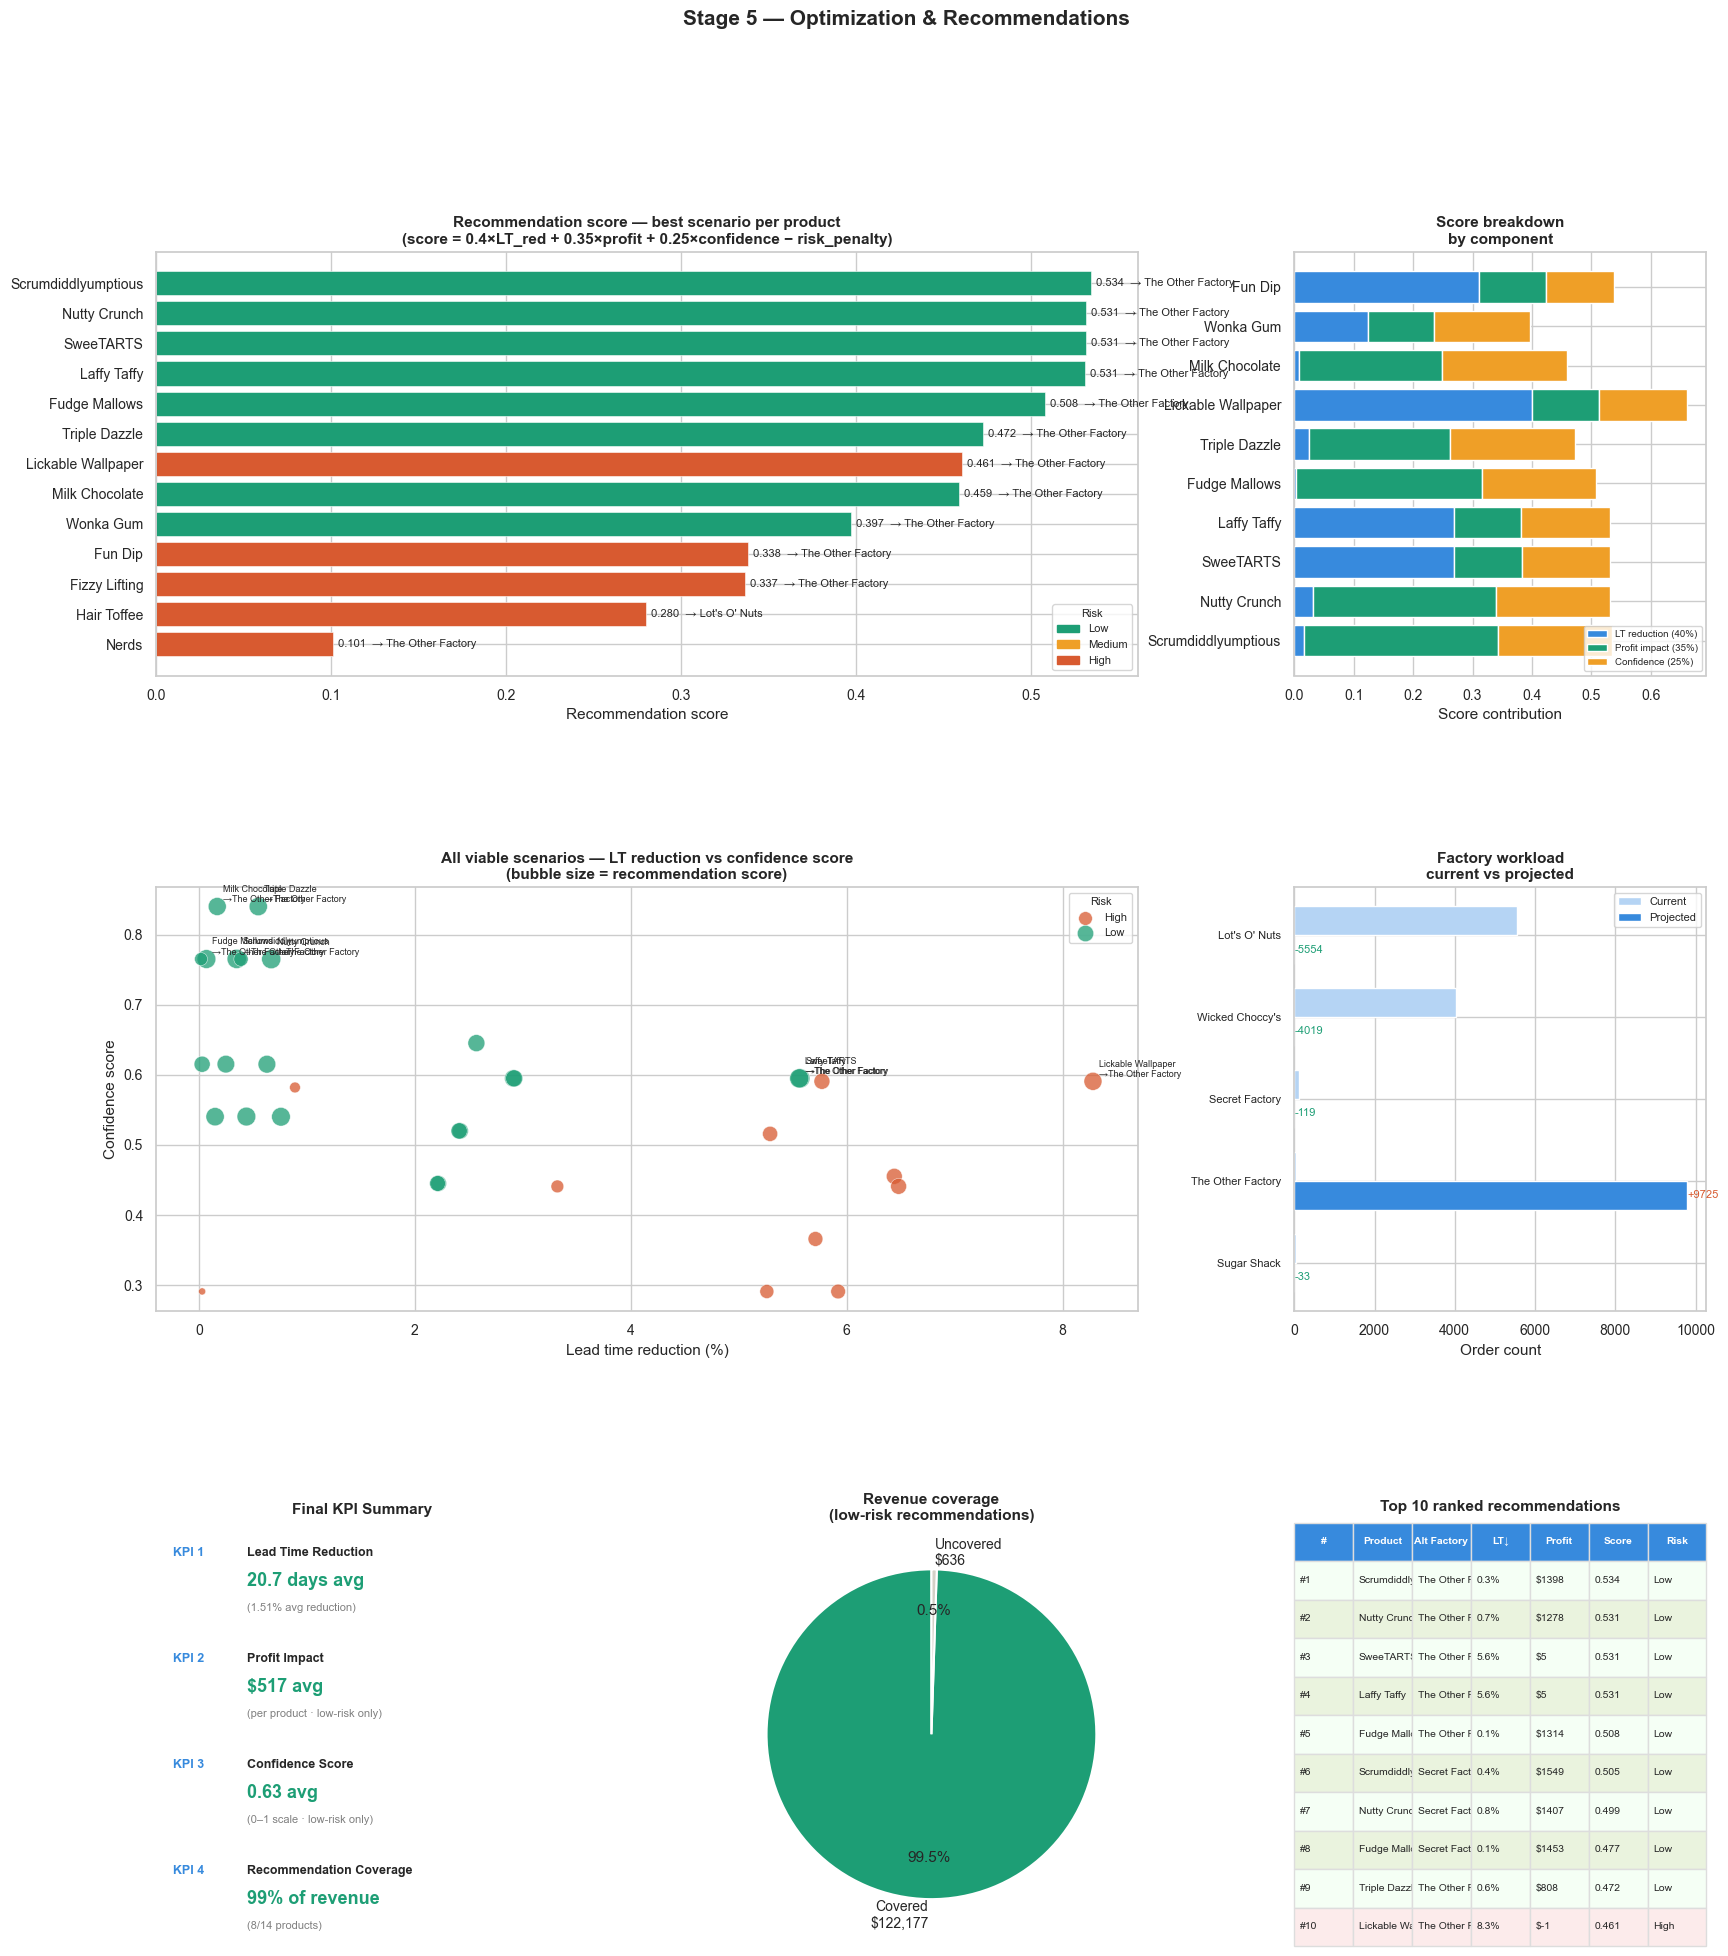

In [6]:
"""
Nassau Candy Distributor — Stage 5: Optimization & Recommendations
==================================================================
Reads from stage4_simulations.csv (output of Stage 4).

Takes all simulated factory-reassignment scenarios and produces ranked,
actionable recommendations using a composite scoring formula:

  Recommendation Score = 0.40 × LT_Reduction_norm
                       + 0.35 × Profit_Impact_norm
                       + 0.25 × Confidence_Score
                       - Risk_Penalty (High=0.20, Medium=0.05, Low=0)

Each metric is min-max normalized before weighting so all components
sit on the same 0–1 scale.

Outputs:
  - Full ranked recommendations table (all viable scenarios)
  - Top-N recommendations per product
  - Factory workload impact (order redistribution analysis)
  - Revenue coverage analysis
  - Final KPI dashboard

Inputs:
  - stage4_simulations.csv
  - nassau_enriched.csv

Outputs:
  - stage5_recommendations.csv   — full ranked table
  - stage5_top_recommendations.csv — top-N per product
  - stage5_recommendations.png   — final dashboard
  - stage5_report.pkl            — packaged for downstream use
"""

# ── 0. Config ──────────────────────────────────────────────────────────────────
TOP_N      = 5    # Top recommendations per product to surface

# Scoring weights (must sum to 1.0 before risk penalty)
W_LT_REDUCTION  = 0.40
W_PROFIT_IMPACT = 0.35
W_CONFIDENCE    = 0.25
RISK_PENALTY    = {'Low': 0.00, 'Medium': 0.05, 'High': 0.20}

PROD_NAMES = {
    'CHO-FUD-51000': 'Fudge Mallows',       'CHO-MIL-31000': 'Milk Chocolate',
    'CHO-NUT-13000': 'Nutty Crunch',        'CHO-SCR-58000': 'Scrumdiddlyumptious',
    'CHO-TRI-54000': 'Triple Dazzle',       'OTH-FIZ-56000': 'Fizzy Lifting',
    'OTH-GUM-21000': 'Wonka Gum',           'OTH-KAZ-38000': 'Kazookles',
    'OTH-LIC-15000': 'Lickable Wallpaper',  'SUG-FUN-75000': 'Fun Dip',
    'SUG-HAI-55000': 'Hair Toffee',         'SUG-LAF-25000': 'Laffy Taffy',
    'SUG-NER-92000': 'Nerds',               'SUG-SWE-91000': 'SweeTARTS',
}

print("=" * 65)
print("STAGE 5: OPTIMIZATION & RECOMMENDATIONS")
print("=" * 65)

# ── 1. Load inputs ─────────────────────────────────────────────────────────────
sim_df = pd.read_csv(f"{OUTPUT_DIR}/stage4_simulations.csv")
enrich = pd.read_csv(f"{OUTPUT_DIR}/nassau_enriched.csv")

# Revenue lookup by product
revenue_map = enrich.groupby('Product ID')['Sales'].sum().to_dict()
order_map   = enrich.groupby('Product ID')['Sales'].count().to_dict()

print(f"\n✔ Loaded {len(sim_df)} simulated scenarios across "
      f"{sim_df['Product ID'].nunique()} products")

# ── 2. Filter viable scenarios ─────────────────────────────────────────────────
# Keep all scenarios with positive LT reduction for scoring
# (negative scenarios are still stored but ranked at the bottom)
viable = sim_df[sim_df['LT Reduction (%)'] > 0].copy()
print(f"   Viable scenarios (LT reduction > 0): {len(viable)}")

# ── 3. Normalize KPI components (min-max, 0–1) ────────────────────────────────
def minmax(series):
    rng = series.max() - series.min()
    if rng == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - series.min()) / rng

viable['LT_norm']     = minmax(viable['LT Reduction (%)'])
viable['Profit_norm'] = minmax(viable['Profit Impact ($)'])
# Confidence already 0–1
viable['Conf_norm']   = viable['Confidence Score']

# ── 4. Composite recommendation score ─────────────────────────────────────────
viable['Risk_Penalty'] = viable['Risk'].map(RISK_PENALTY)

viable['Recommendation Score'] = (
    W_LT_REDUCTION  * viable['LT_norm'] +
    W_PROFIT_IMPACT * viable['Profit_norm'] +
    W_CONFIDENCE    * viable['Conf_norm'] -
    viable['Risk_Penalty']
).round(4)

viable = viable.sort_values('Recommendation Score', ascending=False).reset_index(drop=True)
viable['Rank'] = viable.index + 1

# Add revenue impact column
viable['Product Revenue ($)'] = viable['Product ID'].map(revenue_map).round(2)

print(f"\n── Scoring Formula ──")
print(f"   Score = {W_LT_REDUCTION}×LT_reduction_norm"
      f" + {W_PROFIT_IMPACT}×Profit_norm"
      f" + {W_CONFIDENCE}×Confidence - Risk_penalty")
print(f"   Risk penalties: Low={RISK_PENALTY['Low']}, "
      f"Medium={RISK_PENALTY['Medium']}, High={RISK_PENALTY['High']}")

# ── 5. Top-N per product ───────────────────────────────────────────────────────
top_n = (viable.groupby('Product ID')
               .head(1)
               .sort_values('Recommendation Score', ascending=False)
               .reset_index(drop=True))
top_n['Rank'] = top_n.index + 1

# ── 6. Print ranked recommendations ───────────────────────────────────────────
print(f"\n── Top Recommendations (best per product, ranked by score) ──\n")
print(f"  {'#':<3} {'Product':<25} {'From':<20} {'To':<20} "
      f"{'LT↓(%)':>7} {'LT↓(d)':>7} {'Profit($)':>10} "
      f"{'Conf':>5} {'Score':>6} {'Risk':<8}")
print("  " + "─" * 115)
for _, r in top_n.iterrows():
    print(f"  {int(r['Rank']):<3} {r['Product Name']:<25} "
          f"{r['Current Factory']:<20} → {r['Alternate Factory']:<20} "
          f"{r['LT Reduction (%)']:>6.1f}% "
          f"{r['LT Reduction (days)']:>6.0f}d "
          f"${r['Profit Impact ($)']:>8.0f} "
          f"{r['Confidence Score']:>5.2f} "
          f"{r['Recommendation Score']:>6.4f} "
          f"{r['Risk']:<8}")

# ── 7. Factory workload impact ─────────────────────────────────────────────────
print(f"\n── Factory Workload Impact (if top recommendations actioned) ──\n")

current_load  = enrich['Factory'].value_counts().reset_index()
current_load.columns = ['Factory', 'Current Orders']

# Simulate order redistribution based on top-n reassignments
order_delta = {}
for _, r in top_n.iterrows():
    delta = r['Order Count']
    order_delta[r['Current Factory']]   = order_delta.get(r['Current Factory'],   0) - delta
    order_delta[r['Alternate Factory']] = order_delta.get(r['Alternate Factory'], 0) + delta

current_load['Order Delta']   = current_load['Factory'].map(order_delta).fillna(0).astype(int)
current_load['Projected Orders'] = current_load['Current Orders'] + current_load['Order Delta']
current_load['Load Change (%)']  = (
    current_load['Order Delta'] / current_load['Current Orders'] * 100
).round(1)
print(current_load.to_string(index=False))

# ── 8. Revenue coverage analysis ──────────────────────────────────────────────
total_revenue    = sum(revenue_map.values())
covered_products = top_n[top_n['Risk'] != 'High']['Product ID'].unique()
covered_revenue  = sum(revenue_map.get(pid, 0) for pid in covered_products)
coverage_pct     = covered_revenue / total_revenue * 100

print(f"\n── Revenue Coverage ──")
print(f"   Total product revenue    : ${total_revenue:,.2f}")
print(f"   Revenue covered by recs  : ${covered_revenue:,.2f}  ({coverage_pct:.1f}%)")
print(f"   Products with Low-risk rec: {len(covered_products)} / "
      f"{sim_df['Product ID'].nunique()}")

# ── 9. KPI Summary ────────────────────────────────────────────────────────────
low_risk = viable[viable['Risk'] == 'Low']
print(f"\n── Final KPI Summary ──")
print(f"   KPI 1  Lead Time Reduction  : "
      f"{low_risk['LT Reduction (days)'].mean():.1f} days avg  "
      f"({low_risk['LT Reduction (%)'].mean():.2f}% avg)")
print(f"   KPI 2  Profit Impact        : "
      f"${low_risk['Profit Impact ($)'].mean():.0f} avg per product")
print(f"   KPI 3  Confidence Score     : "
      f"{low_risk['Confidence Score'].mean():.4f} avg")
print(f"   KPI 4  Recommendation Coverage: "
      f"{coverage_pct:.1f}% of revenue  "
      f"({len(covered_products)}/{sim_df['Product ID'].nunique()} products)")

# ── 10. Visualization ──────────────────────────────────────────────────────────
risk_palette = {'Low': '#1D9E75', 'Medium': '#EF9F27', 'High': '#D85A30'}
div_palette  = {'Chocolate': '#378ADD', 'Sugar': '#EF9F27', 'Other': '#1D9E75'}

sns.set_theme(style='whitegrid', font_scale=0.92)
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Stage 5 — Optimization & Recommendations',
             fontsize=15, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# ── 10a. Ranked recommendation score (best per product) ───────────────────────
ax1 = fig.add_subplot(gs[0, :2])
top_sorted = top_n.sort_values('Recommendation Score')
bar_colors = [risk_palette[r] for r in top_sorted['Risk']]
bars = ax1.barh(top_sorted['Product Name'], top_sorted['Recommendation Score'],
                color=bar_colors, edgecolor='white', linewidth=0.4)
for bar, val, fac in zip(bars, top_sorted['Recommendation Score'],
                          top_sorted['Alternate Factory']):
    ax1.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}  → {fac}', va='center', fontsize=8)
ax1.set_title('Recommendation score — best scenario per product\n'
              f'(score = {W_LT_REDUCTION}×LT_red + {W_PROFIT_IMPACT}×profit + '
              f'{W_CONFIDENCE}×confidence − risk_penalty)',
              fontweight='bold')
ax1.set_xlabel('Recommendation score')
legend_patches = [mpatches.Patch(color=c, label=l)
                  for l, c in risk_palette.items()]
ax1.legend(handles=legend_patches, title='Risk', fontsize=8, title_fontsize=8)

# ── 10b. Score components stacked bar ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
top_plot = top_n.sort_values('Recommendation Score', ascending=False).head(10)
ax2.barh(top_plot['Product Name'],
         W_LT_REDUCTION  * top_plot['LT_norm'],
         label=f'LT reduction ({int(W_LT_REDUCTION*100)}%)',
         color='#378ADD', edgecolor='white')
ax2.barh(top_plot['Product Name'],
         W_PROFIT_IMPACT * top_plot['Profit_norm'],
         left=W_LT_REDUCTION * top_plot['LT_norm'],
         label=f'Profit impact ({int(W_PROFIT_IMPACT*100)}%)',
         color='#1D9E75', edgecolor='white')
ax2.barh(top_plot['Product Name'],
         W_CONFIDENCE    * top_plot['Conf_norm'],
         left=(W_LT_REDUCTION * top_plot['LT_norm'] +
               W_PROFIT_IMPACT * top_plot['Profit_norm']),
         label=f'Confidence ({int(W_CONFIDENCE*100)}%)',
         color='#EF9F27', edgecolor='white')
ax2.set_title('Score breakdown\nby component', fontweight='bold')
ax2.set_xlabel('Score contribution')
ax2.legend(fontsize=7, loc='lower right')

# ── 10c. LT reduction vs confidence scatter (all viable) ─────────────────────
ax3 = fig.add_subplot(gs[1, :2])
for risk, grp in viable.groupby('Risk'):
    ax3.scatter(grp['LT Reduction (%)'], grp['Confidence Score'],
                c=risk_palette[risk], label=risk,
                s=grp['Recommendation Score'] * 300 + 30,
                alpha=0.75, edgecolors='white', linewidth=0.4)
for _, r in top_n.head(8).iterrows():
    ax3.annotate(
        f"{r['Product Name']}\n→{r['Alternate Factory']}",
        (r['LT Reduction (%)'], r['Confidence Score']),
        fontsize=6.5, xytext=(4, 3), textcoords='offset points'
    )
ax3.set_title('All viable scenarios — LT reduction vs confidence score\n'
              '(bubble size = recommendation score)',
              fontweight='bold')
ax3.set_xlabel('Lead time reduction (%)')
ax3.set_ylabel('Confidence score')
ax3.legend(title='Risk', fontsize=8, title_fontsize=8)

# ── 10d. Factory workload chart ───────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
wl = current_load.sort_values('Current Orders', ascending=True)
x = np.arange(len(wl))
w = 0.35
bars_curr = ax4.barh(x + w/2, wl['Current Orders'],
                     height=w, color='#B5D4F4', edgecolor='white', label='Current')
bars_proj = ax4.barh(x - w/2, wl['Projected Orders'],
                     height=w, color='#378ADD', edgecolor='white', label='Projected')
ax4.set_yticks(x)
ax4.set_yticklabels(wl['Factory'], fontsize=8)
ax4.set_title('Factory workload\ncurrent vs projected', fontweight='bold')
ax4.set_xlabel('Order count')
ax4.legend(fontsize=8)
for bar, delta in zip(bars_proj, wl['Order Delta']):
    if delta != 0:
        ax4.text(bar.get_width() + 10,
                 bar.get_y() + bar.get_height()/2,
                 f'{delta:+d}', va='center', fontsize=8,
                 color='#1D9E75' if delta < 0 else '#D85A30')

# ── 10e. KPI cards ────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
ax5.axis('off')
kpis = [
    ('KPI 1', 'Lead Time Reduction',
     f"{low_risk['LT Reduction (days)'].mean():.1f} days avg",
     f"({low_risk['LT Reduction (%)'].mean():.2f}% avg reduction)"),
    ('KPI 2', 'Profit Impact',
     f"${low_risk['Profit Impact ($)'].mean():.0f} avg",
     '(per product · low-risk only)'),
    ('KPI 3', 'Confidence Score',
     f"{low_risk['Confidence Score'].mean():.2f} avg",
     '(0–1 scale · low-risk only)'),
    ('KPI 4', 'Recommendation Coverage',
     f"{coverage_pct:.0f}% of revenue",
     f"({len(covered_products)}/{sim_df['Product ID'].nunique()} products)"),
]
y = 0.92
for kid, kname, val, sub in kpis:
    ax5.text(0.04, y,      kid,   fontsize=9,  fontweight='bold',
             color='#378ADD', transform=ax5.transAxes)
    ax5.text(0.22, y,      kname, fontsize=9,  fontweight='bold',
             transform=ax5.transAxes)
    ax5.text(0.22, y-0.07, val,   fontsize=13, fontweight='bold',
             color='#1D9E75', transform=ax5.transAxes)
    ax5.text(0.22, y-0.13, sub,   fontsize=8,  color='gray',
             transform=ax5.transAxes)
    y -= 0.25
ax5.set_title('Final KPI Summary', fontweight='bold')

# ── 10f. Revenue coverage donut ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
covered_rev   = sum(revenue_map.get(pid, 0) for pid in covered_products)
uncovered_rev = total_revenue - covered_rev
ax6.pie([covered_rev, uncovered_rev],
        labels=[f'Covered\n${covered_rev:,.0f}',
                f'Uncovered\n${uncovered_rev:,.0f}'],
        colors=['#1D9E75', '#D3D1C7'],
        autopct='%1.1f%%', startangle=90, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax6.set_title('Revenue coverage\n(low-risk recommendations)', fontweight='bold')

# ── 10g. Top 10 full ranked table ─────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
ax7.axis('off')
top10 = viable.head(10)
table_data = []
for _, r in top10.iterrows():
    table_data.append([
        f"#{int(r['Rank'])}",
        r['Product Name'][:16],
        r['Alternate Factory'][:16],
        f"{r['LT Reduction (%)']:.1f}%",
        f"${r['Profit Impact ($)']:.0f}",
        f"{r['Recommendation Score']:.3f}",
        r['Risk'],
    ])
table = ax7.table(
    cellText=table_data,
    colLabels=['#', 'Product', 'Alt Factory', 'LT↓', 'Profit', 'Score', 'Risk'],
    cellLoc='left', loc='center', bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(7.5)
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if row_idx == 0:
        cell.set_facecolor('#378ADD')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        risk_val = table_data[row_idx-1][6] if row_idx <= len(table_data) else 'Low'
        if risk_val == 'Low':
            cell.set_facecolor('#EAF3DE' if row_idx % 2 == 0 else '#f5fff5')
        elif risk_val == 'High':
            cell.set_facecolor('#FCEBEB' if row_idx % 2 == 0 else '#fff5f5')
        else:
            cell.set_facecolor('#FAEEDA' if row_idx % 2 == 0 else '#fffbf0')
ax7.set_title('Top 10 ranked recommendations', fontweight='bold', pad=8)

plt.savefig(f'{OUTPUT_DIR}/stage5_recommendations.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n✔ Chart saved → stage5_recommendations.png")

# ── 11. Save outputs ───────────────────────────────────────────────────────────
# Full ranked table
out_cols = ['Rank', 'Product ID', 'Product Name', 'Division',
            'Current Factory', 'Alternate Factory',
            'Current Avg LT (days)', 'Simulated Avg LT (days)',
            'LT Reduction (days)', 'LT Reduction (%)',
            'Distance Delta (mi)', 'Avg Gross Profit ($)',
            'Profit Impact ($)', 'Confidence Score',
            'Current Route Cluster', 'Alternate Route Cluster',
            'Recommendation Score', 'Risk', 'Order Count', 'Product Revenue ($)']
viable[out_cols].to_csv(f'{OUTPUT_DIR}/stage5_recommendations.csv', index=False)
top_n[out_cols].to_csv(f'{OUTPUT_DIR}/stage5_top_recommendations.csv', index=False)

with open(f'{OUTPUT_DIR}/stage5_report.pkl', 'wb') as f:
    pickle.dump({
        'ranked_recommendations': viable,
        'top_per_product':        top_n,
        'factory_workload':       current_load,
        'kpis': {
            'avg_lt_reduction_days':   round(low_risk['LT Reduction (days)'].mean(), 2),
            'avg_lt_reduction_pct':    round(low_risk['LT Reduction (%)'].mean(), 2),
            'avg_profit_impact':       round(low_risk['Profit Impact ($)'].mean(), 2),
            'avg_confidence':          round(low_risk['Confidence Score'].mean(), 4),
            'revenue_coverage_pct':    round(coverage_pct, 1),
            'products_covered':        len(covered_products),
            'total_products':          sim_df['Product ID'].nunique(),
        },
        'weights': {
            'lt_reduction':  W_LT_REDUCTION,
            'profit_impact': W_PROFIT_IMPACT,
            'confidence':    W_CONFIDENCE,
        }
    }, f)

print(f"✔ Full recommendations → stage5_recommendations.csv     ({len(viable)} rows)")
print(f"✔ Top per product      → stage5_top_recommendations.csv ({len(top_n)} rows)")
print(f"✔ Report pkl           → stage5_report.pkl")
print(f"\n{'=' * 65}")
print(f"Stage 5 complete.")
print(f"Pipeline fully built. All stages 1–5 complete.")
print("=" * 65)